# QC Processing Workflow

This notebook performs quality control and preprocessing of flow cytometry data for multiple cell types (B cells, T cells, Myeloid, Survey) across Flu and Multiple Myeloma (MM) studies.

## Workflow Steps:

1. **Data Loading & Setup**: Load libraries, import raw flow cytometry files, and define timepoint mappings
2. **Preprocessing QC**: Analyze column consistency, population naming, and duplicate measurements with visualizations
3. **Data Processing & Standardization**: Apply duplicate handling, column standardization, and ALC normalization
4. **Post-Processing QC**: Generate sample availability heatmaps and data validation
5. **Data Export**: Save processed datasets as separate CSV files by study type and cell type

## 1. Data Loading & Setup

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(ggalluvial)
    library(dplyr)
    library(RColorBrewer)
    library(gridExtra)
    library(rlang)
    library(tidyr)
    library(patchwork)
    library(data.table)
    library(ggpubr)
    library(tidyverse)
})

file_paths <- list.files("data", pattern = "Statistics", recursive = TRUE, full.names = TRUE)

panels <- list(
    "PB1" = c("B cell", "bcell"),
    "PS1" = c("Survey", "survey"),
    "PT1" = c("T cell", "tcell"),
    "PM1" = c("Myeloid", "myeloid")
)

raw_dfs <- lapply(file_paths, function(path) {
    df <- read.csv(path)
    string <- strsplit(path, " ")[[1]][2]
    df$panel <- string
    df$formal_celltype <- panels[[unique(df$panel)]][1]
    df$informal_celltype <- panels[[unique(df$panel)]][2]
    healthy_df=df[df$Cohort=='Healthy',]
    ndmm_df=df[df$Cohort=='FH1',]
    ndmm_df=ndmm_df[ndmm_df$`MM.Visit` %in% c( "MM Pre-Treatment",
                                              "MM Post Induction 2-Cycles",
                                              "MM End Induction 1st Draw",
                                              "MM Post Transplant 60 Days",
                                              "MM Post Transplant 90 Days",
                                              "MM Post Transplant 1 year",
                                              "MM Post Transplant 2 year")
                                              ,]
    df = rbind(healthy_df, ndmm_df)
    return(df)
})

alc_path <- "../data/flow/Total_ALC_Counts.csv"
alc_df <- read.csv(alc_path)

#### Timepoints

In [3]:
flu_timepoints <- c(
    "Flu Year 1 Stand-Alone" = "Y1 SA",
    "Flu Year 1 Day 0" = "Y1 Day 0",
    "Flu Year 1 Day 7" = "Y1 Day 7",
    "Flu Year 1 Day 90" = "Y1 Day 90",
    "Flu Year 2 Stand-Alone" = "Y2 SA",
    "Flu Year 2 Day 0" = "Y2 Day 0",
    "Flu Year 2 Day 7" = "Y2 Day 7", 
    "Flu Year 2 Day 90" = "Y2 Day 90"
)

mm_timepoints <- c(
    "Healthy" = "Healthy",
    "MM Pre-Treatment" = "PreTx",
    "MM Post Induction 2-Cycles" = "PI2C",
    "MM End Induction 1st Draw" = "EI",
    "MM Post Transplant 60 Days" = "ASCT60d",
    "MM Post Transplant 90 Days" = "ASCT90d",
    "MM Post Transplant 1 year" = "ASCT1y",
    "MM Post Transplant 2 year" = "ASCT2y"
)

#### Celltypes

In [4]:
bcell_celltypes <- c(
    "Plasma cells",
    "Effector B cells",
    "IgM- Naive",
    "IgM+ Naive",
    "DN B cells",
    "Non switched effector",
    "IgA+ Memory",
    "Ig- memory", 
    "IgG+ Memory",
    "Transitional B cells",
    "Non-switch memory"
)

tcell_celltypes <- c(
    "Naive CD4 Treg",
    "Memory CD4 Treg",
    "TEMRA CD4",
    "Naive CD4 T cell",
    "EM CD4 T cell",
    "CM CD4+ T cell",
    "T follicular helper",
    "CD4 rm",
    "TEMRA CD8 T cell",
    "Naive CD8 T cell",
    "EM CD8 T cell",
    "CM CD8 T cell",
    "CD8 rm",
    "DN T cells",
    "DP T cells",
    "TCR yd"
)

myeloid_celltypes <- c(
    "CD14 Monocytes",
    "Neutrophils",
    "Intermediate Monocytes",
    "CD16 Monocytes",
    "CD56bright NK cell",
    "CD56dim NK cell",
    "CD16+CD56 dim NK cell",
    "Plasmacytoid DC",
    "cDC1",
    "cDC2",
    "DN DC",
    "CD16+ CD56 dim NK cell",
    "CD56 dim NK cell"
)

survey_celltypes <- unique(raw_dfs[[which(sapply(raw_dfs, function(df) "PS1" %in% df$panel))]]$population)

## 2. Preprocessing QC

### Column Names

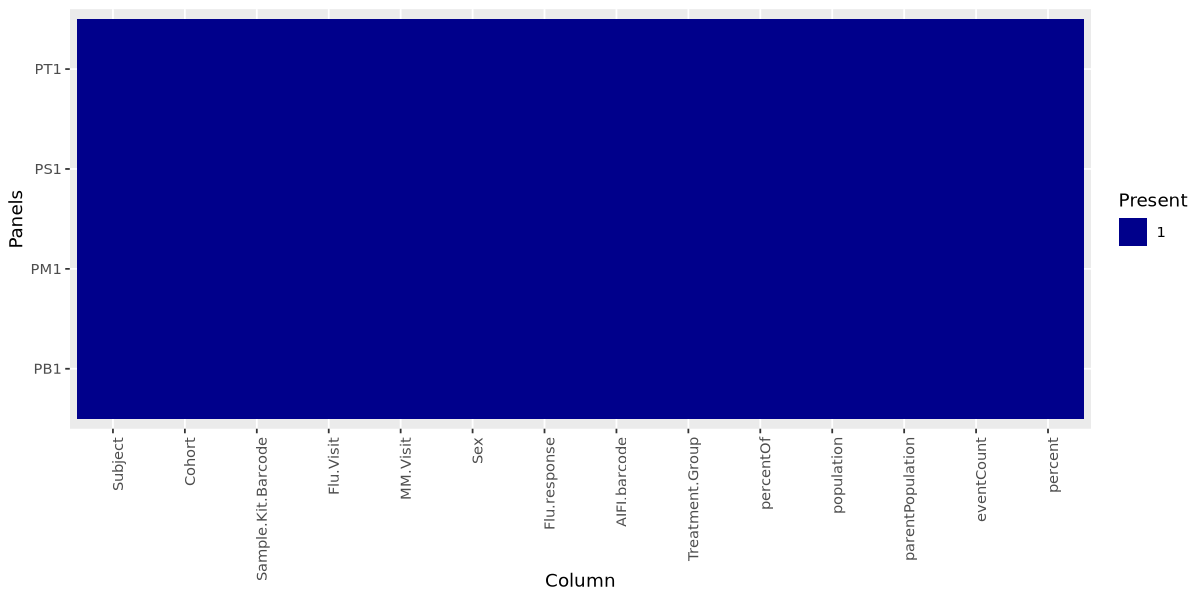

In [5]:
options(repr.plot.width = 10, repr.plot.height = 5)

# Get original columns (before panel column) for each dataframe
col_ls <- lapply(raw_dfs, function(df) {
    panel_pos <- which(names(df) == "panel")
    cols <- names(df)[1:(panel_pos - 1)]
    return(cols)
})
all_cols <- unique(unlist(col_ls))

# Get panel IDs for row names
panel_ids <- sapply(raw_dfs, function(df) unique(df$panel))

# Create binary matrix
col_mtx <- matrix(0, nrow = length(raw_dfs), ncol = length(all_cols))
rownames(col_mtx) <- panel_ids
colnames(col_mtx) <- all_cols

# Fill matrix with original columns only
for(i in 1:length(raw_dfs)) {
  col_mtx[i, col_ls[[i]]] <- 1
}

heatmap_data <- expand.grid(Panels = rownames(col_mtx), Column = colnames(col_mtx))
heatmap_data$Present <- as.vector(col_mtx)

col_plot <- ggplot(heatmap_data, aes(x = Column, y = Panels, fill = factor(Present))) +
  geom_tile() +
  scale_fill_manual(values = c("0" = "white", "1" = "darkblue")) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(fill = "Present")

print(col_plot)

### Population Names

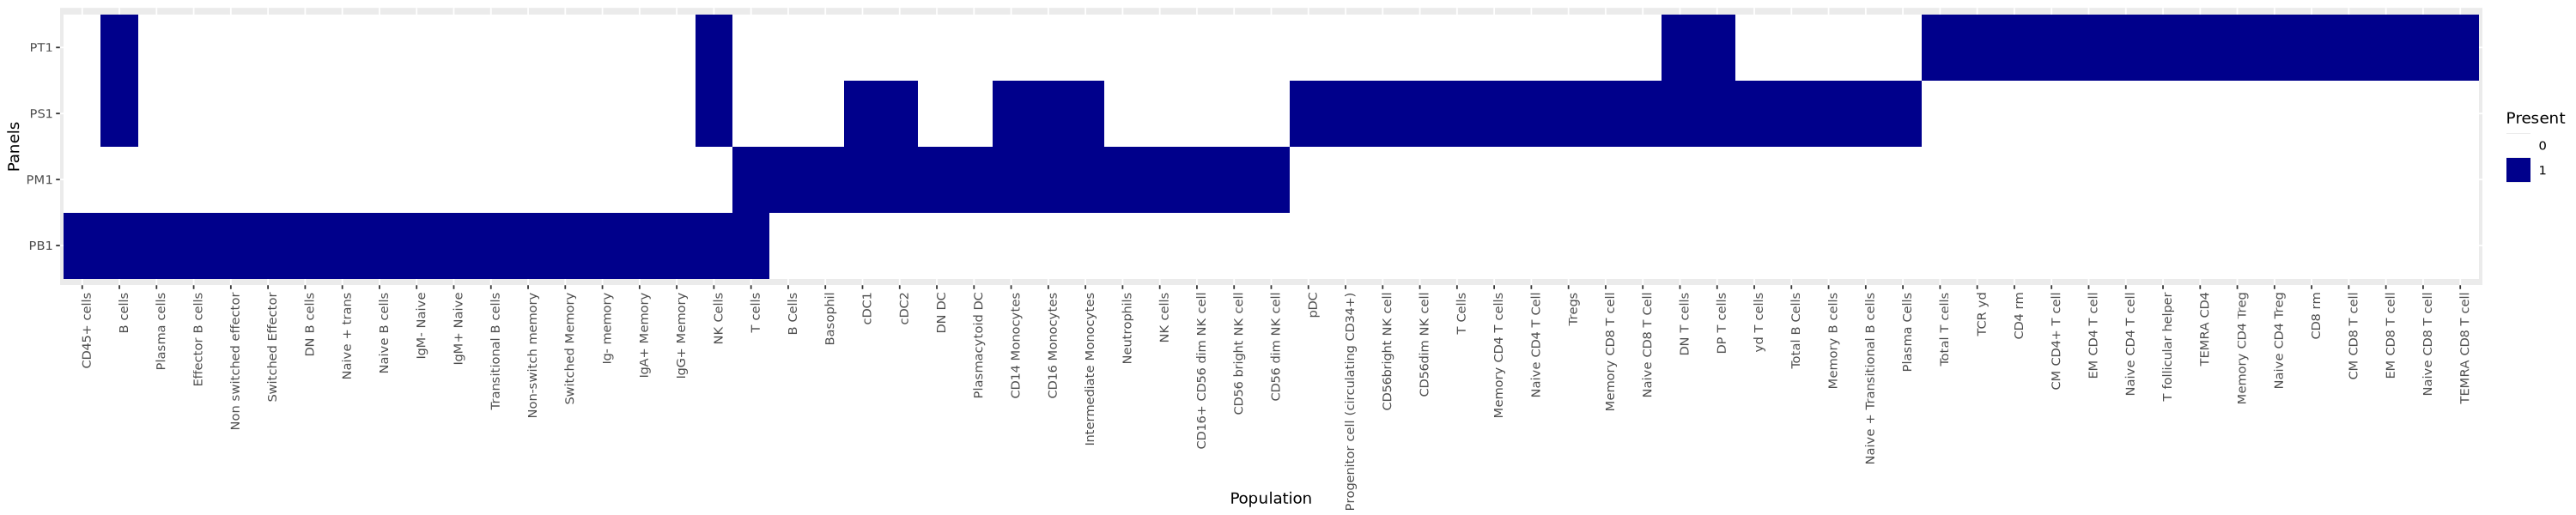

In [6]:
options(repr.plot.width = 25, repr.plot.height = 5)

pop_ls <- lapply(raw_dfs, function(df) {unique(df$population)})
all_pop <- unique(unlist(pop_ls))

panel_ids <- sapply(raw_dfs, function(df) unique(df$panel))

pop_mtx <- matrix(0, nrow = length(raw_dfs), ncol = length(all_pop))
rownames(pop_mtx) <- panel_ids
colnames(pop_mtx) <- all_pop

for(i in 1:length(raw_dfs)) {
  pop_mtx[i, pop_ls[[i]]] <- 1
}

# Convert to long format for ggplot
heatmap_data <- expand.grid(Panels = rownames(pop_mtx), Population = colnames(pop_mtx))
heatmap_data$Present <- as.vector(pop_mtx)

# Create ggplot heatmap
pop_plot <- ggplot(heatmap_data, aes(x = Population, y = Panels, fill = factor(Present))) +
  geom_tile() +
  scale_fill_manual(values = c("0" = "white", "1" = "darkblue")) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(fill = "Present")

print(pop_plot)

### Duplicate Measurements

[[1]]

[[2]]


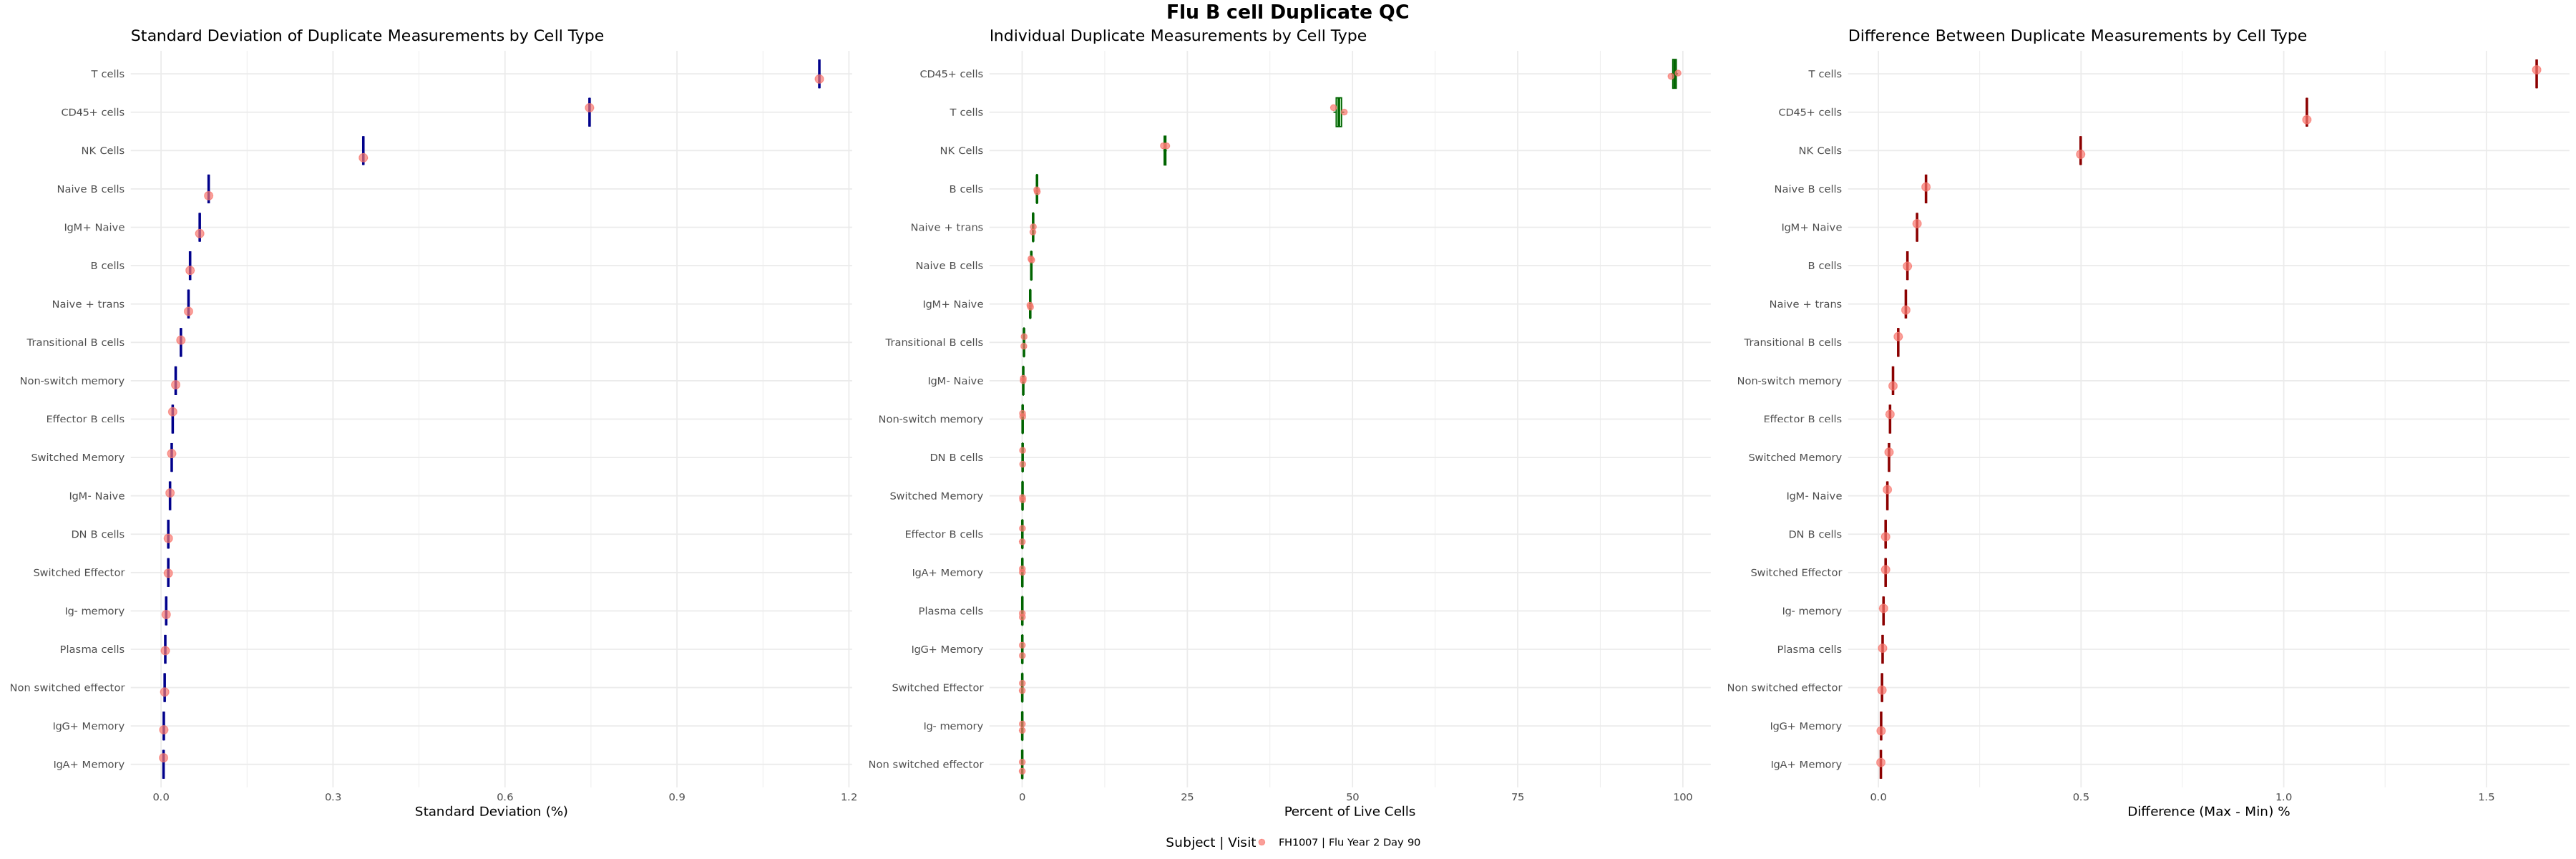


[[3]]


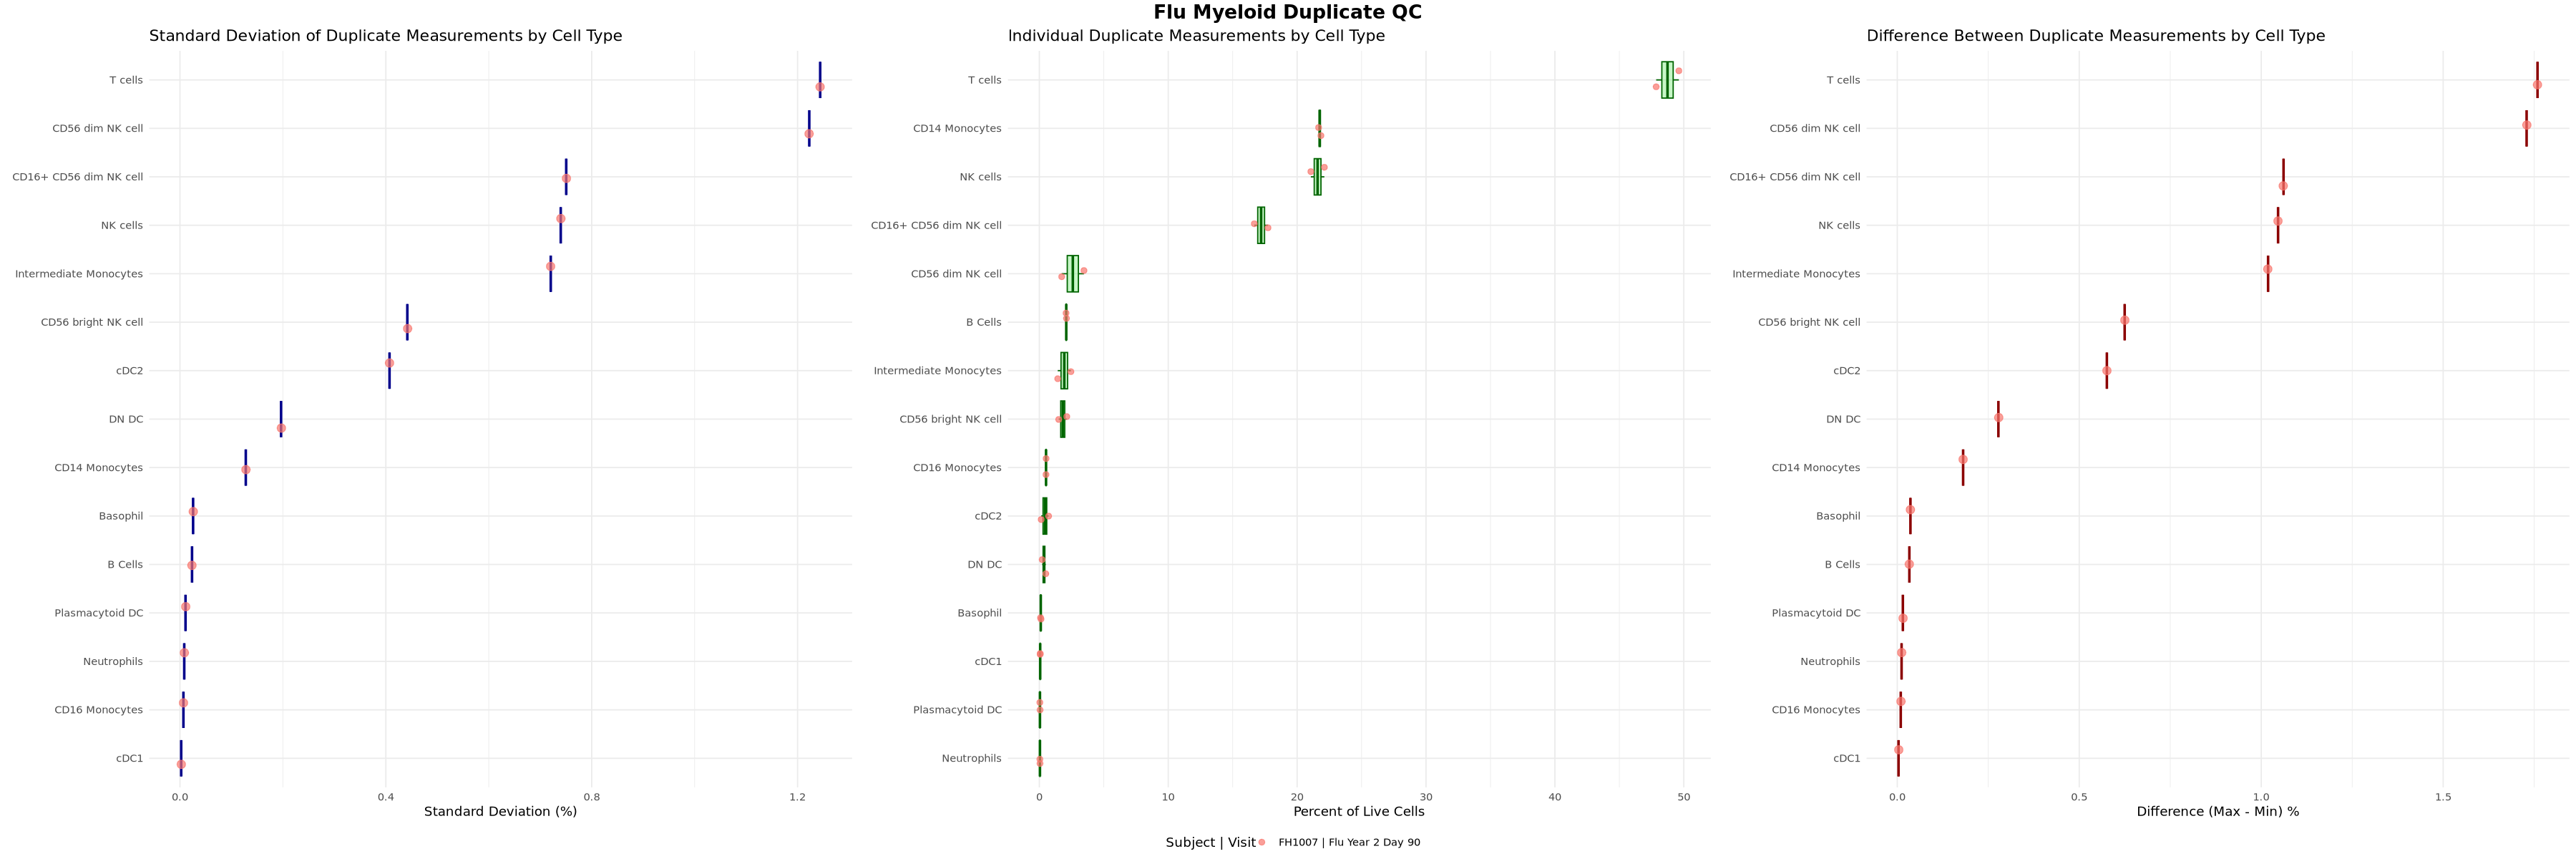


[[4]]


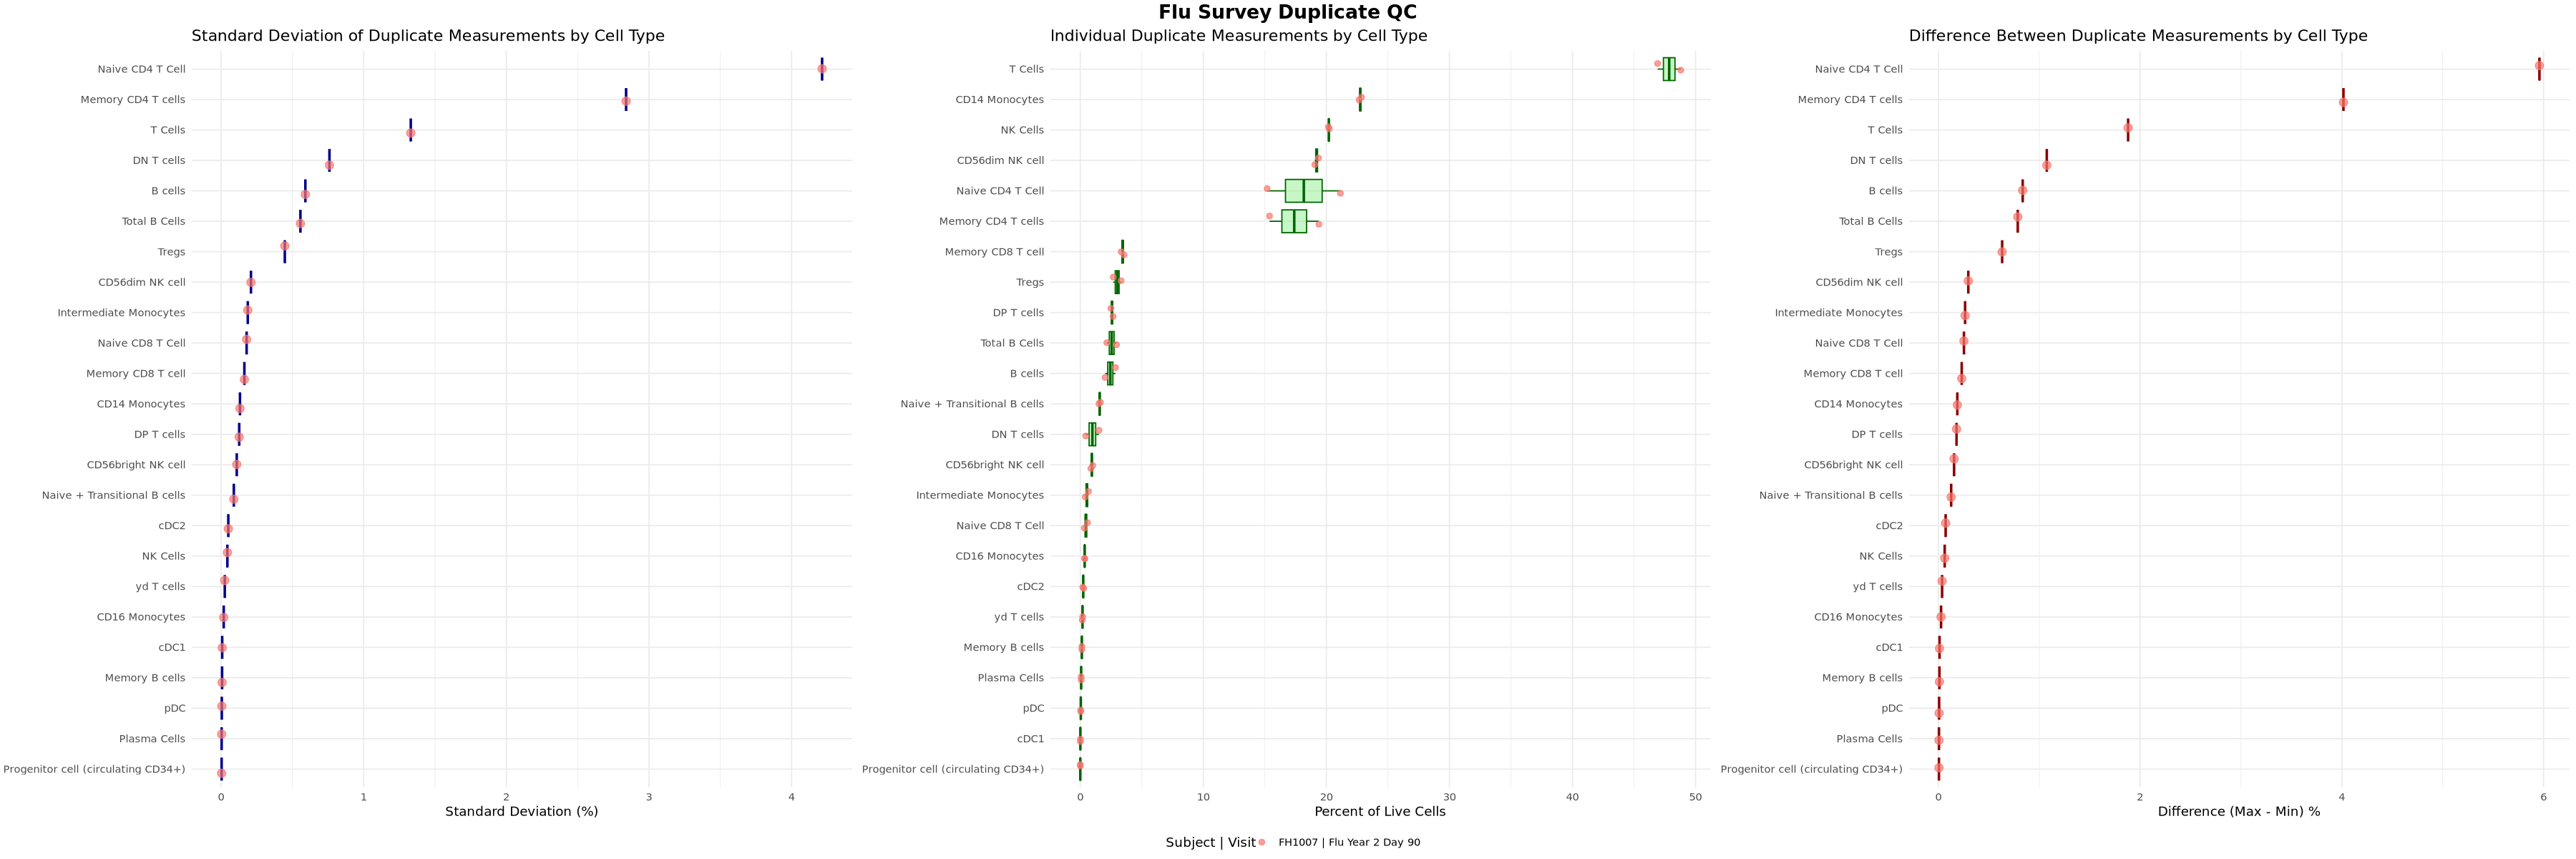


[[1]]


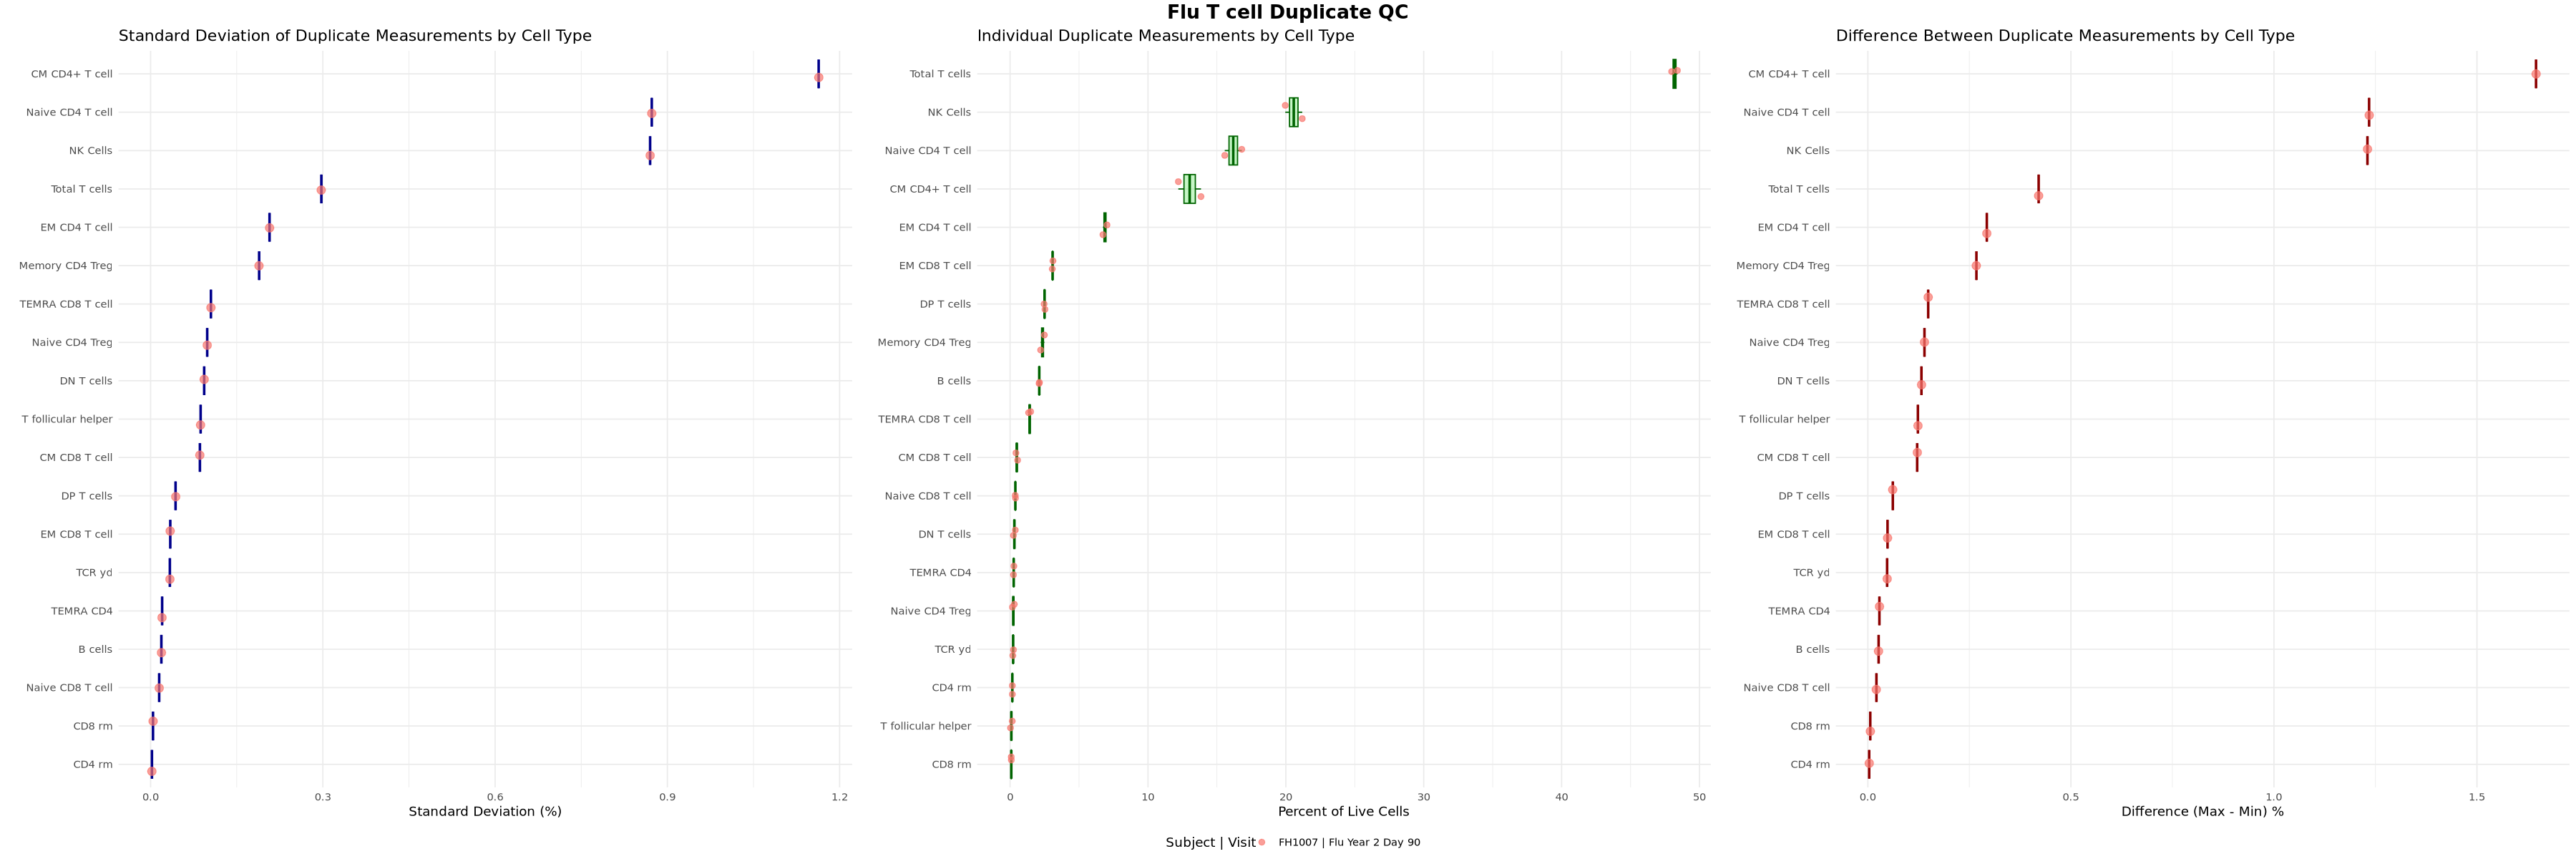


[[2]]


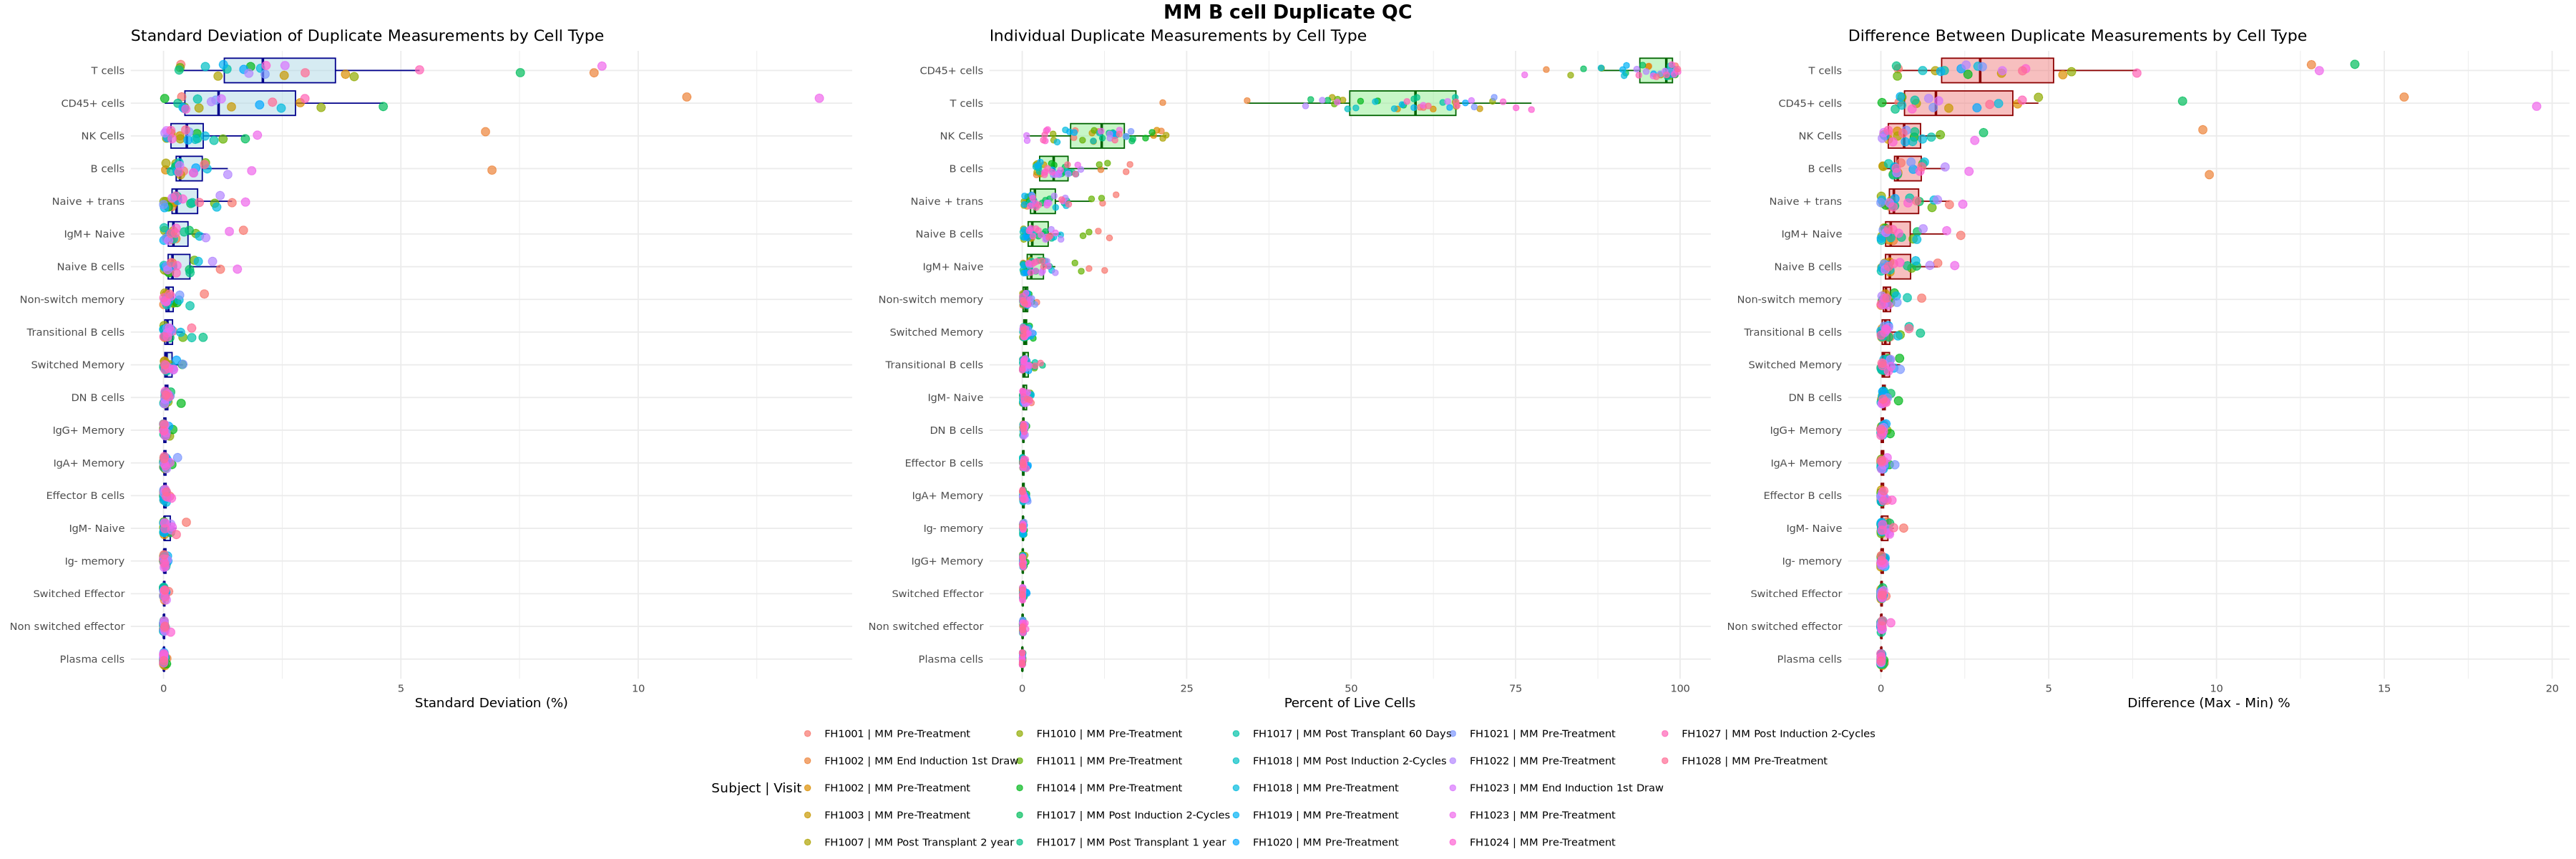


[[3]]


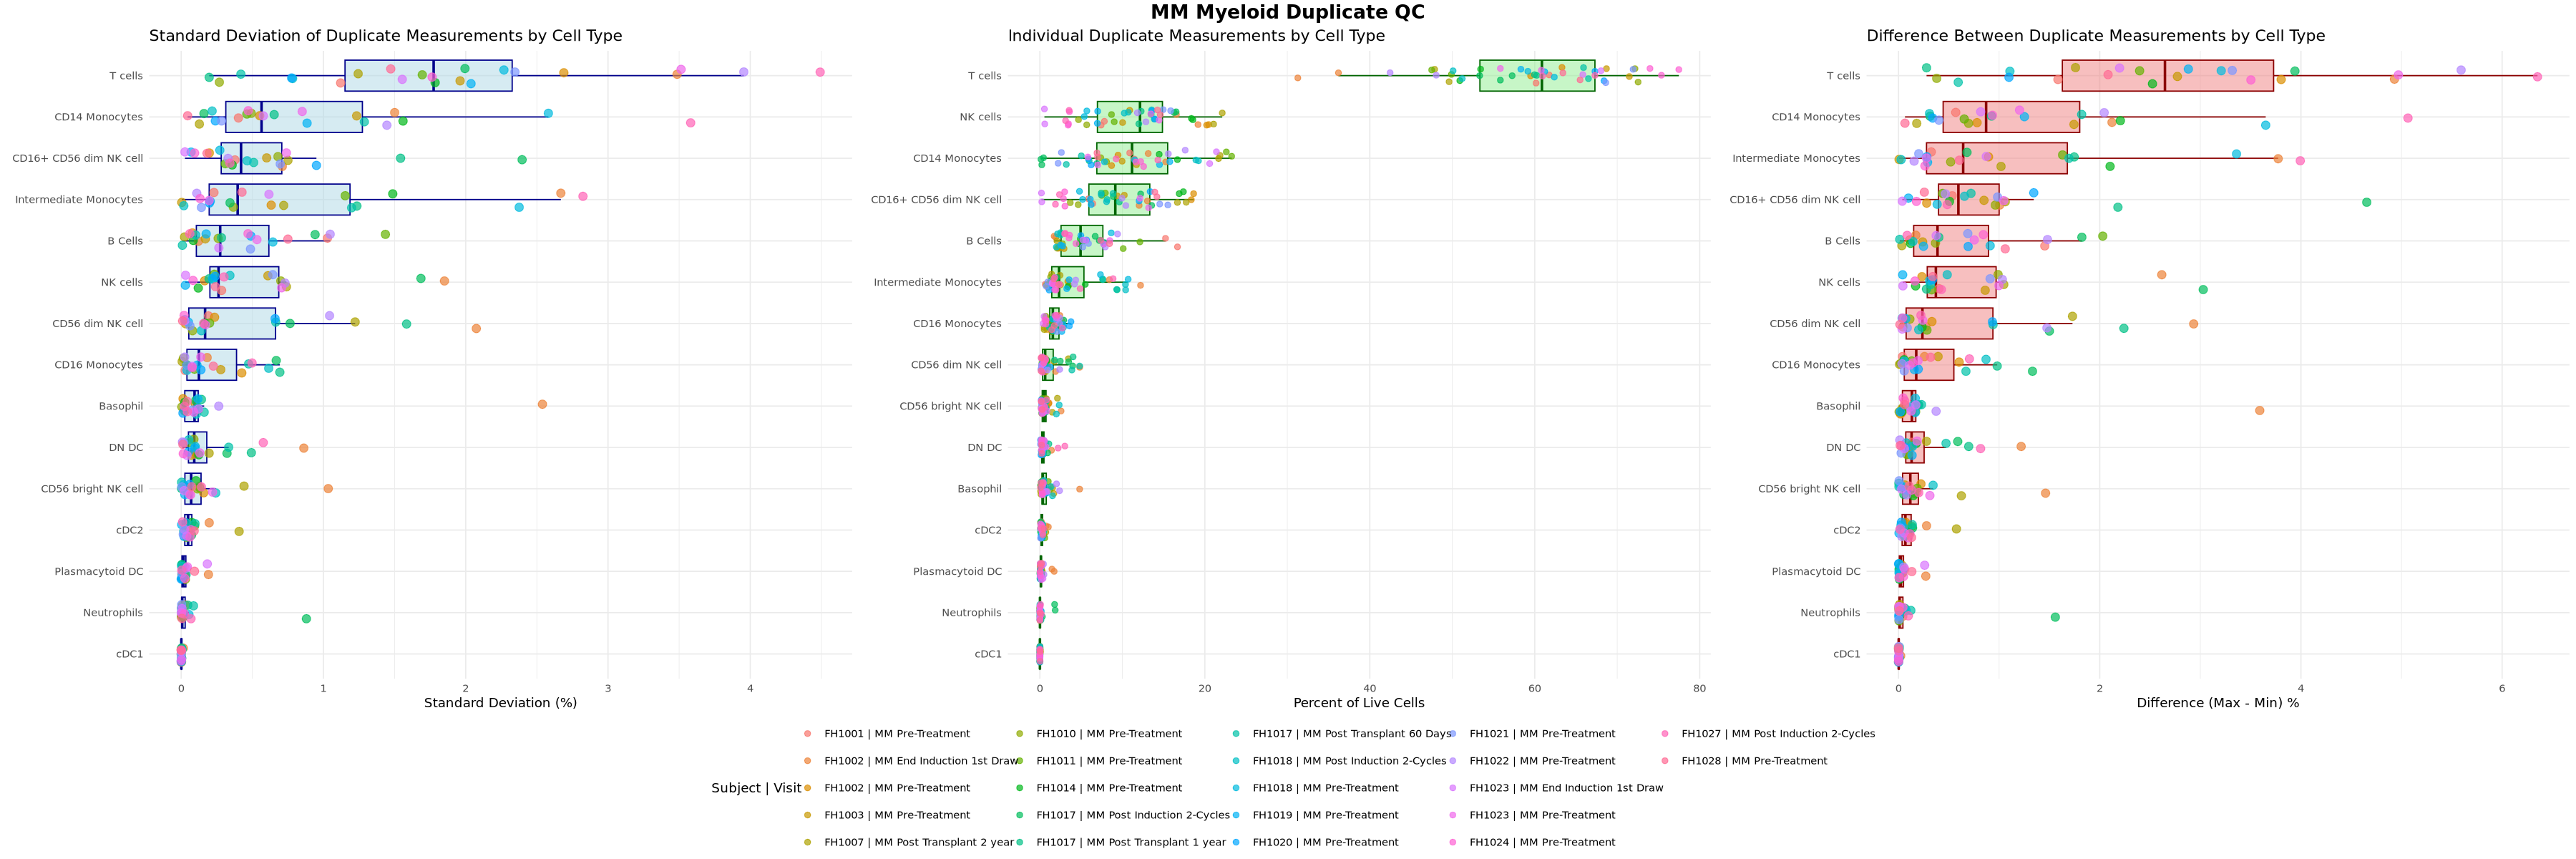


[[4]]


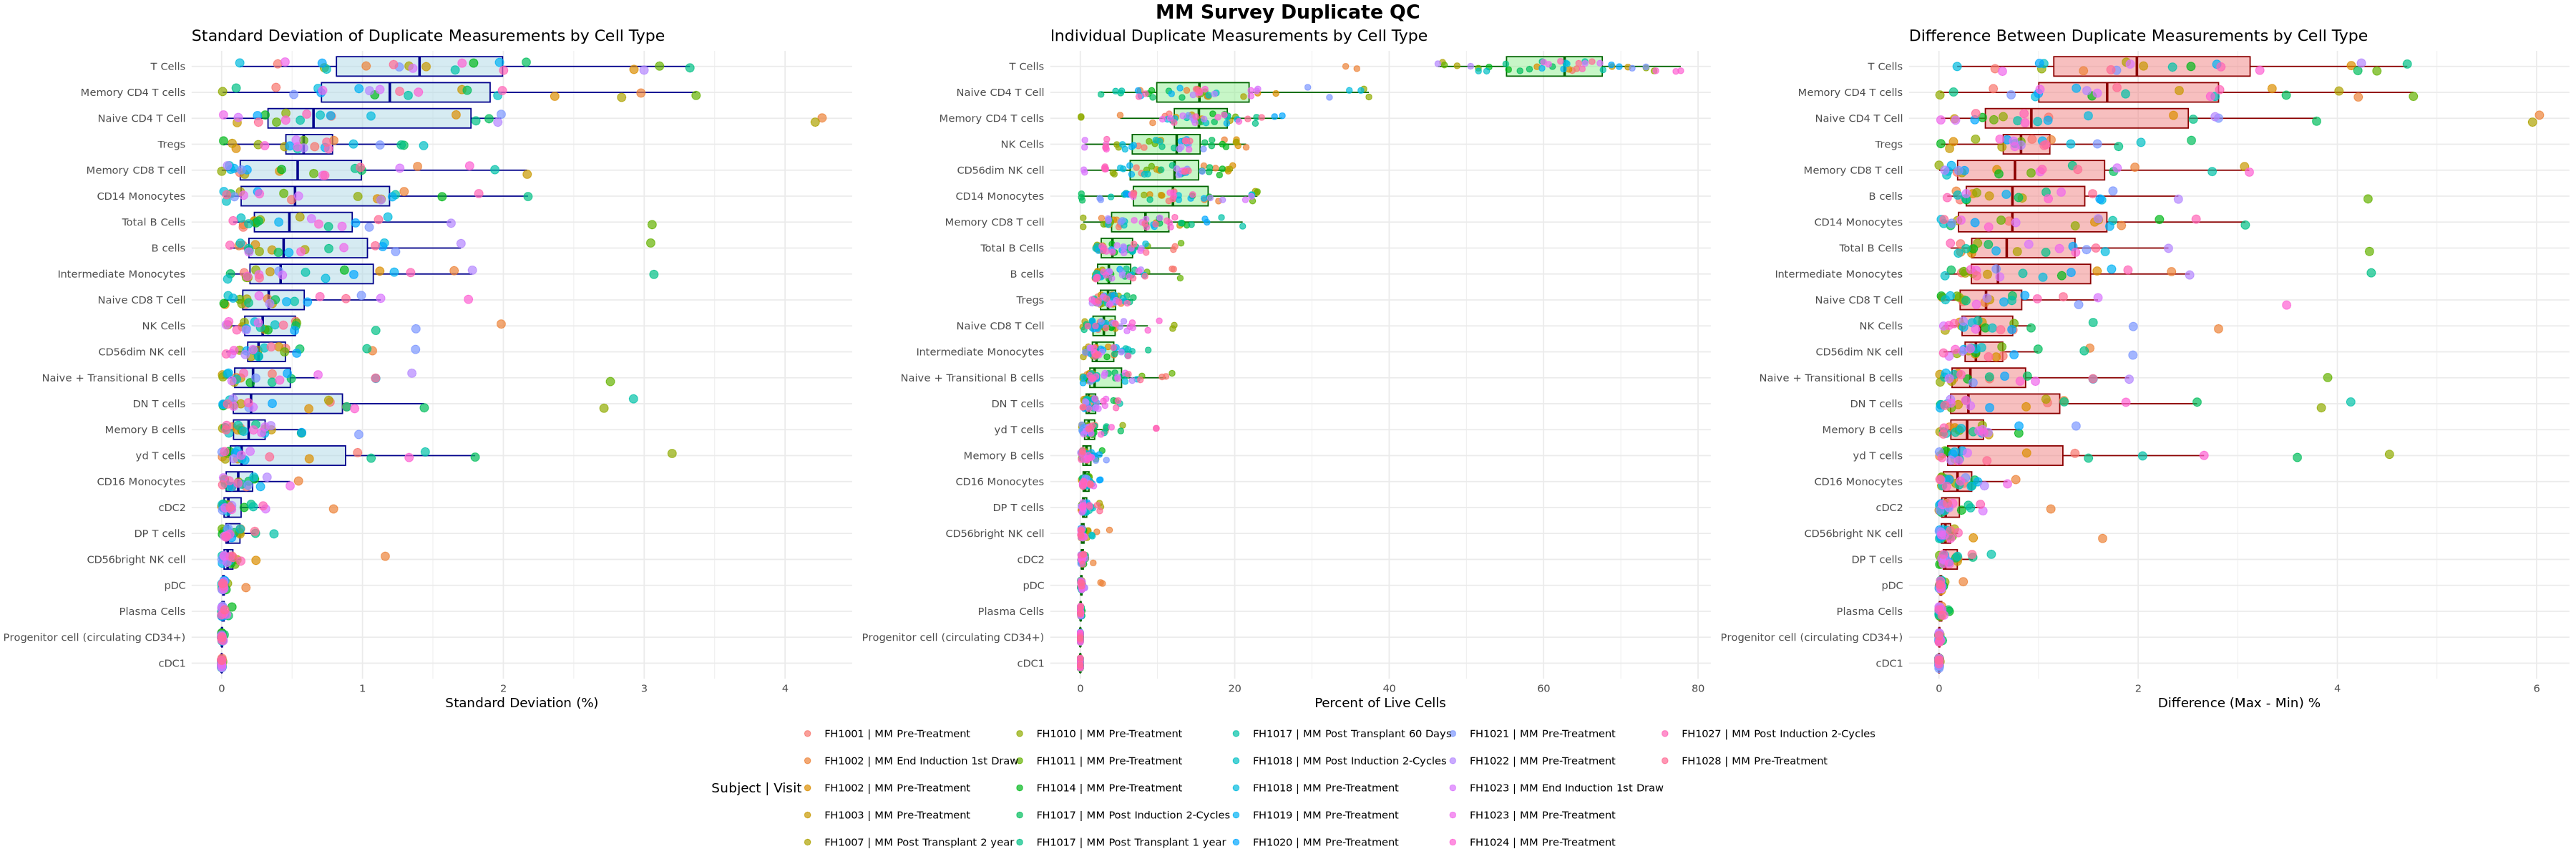

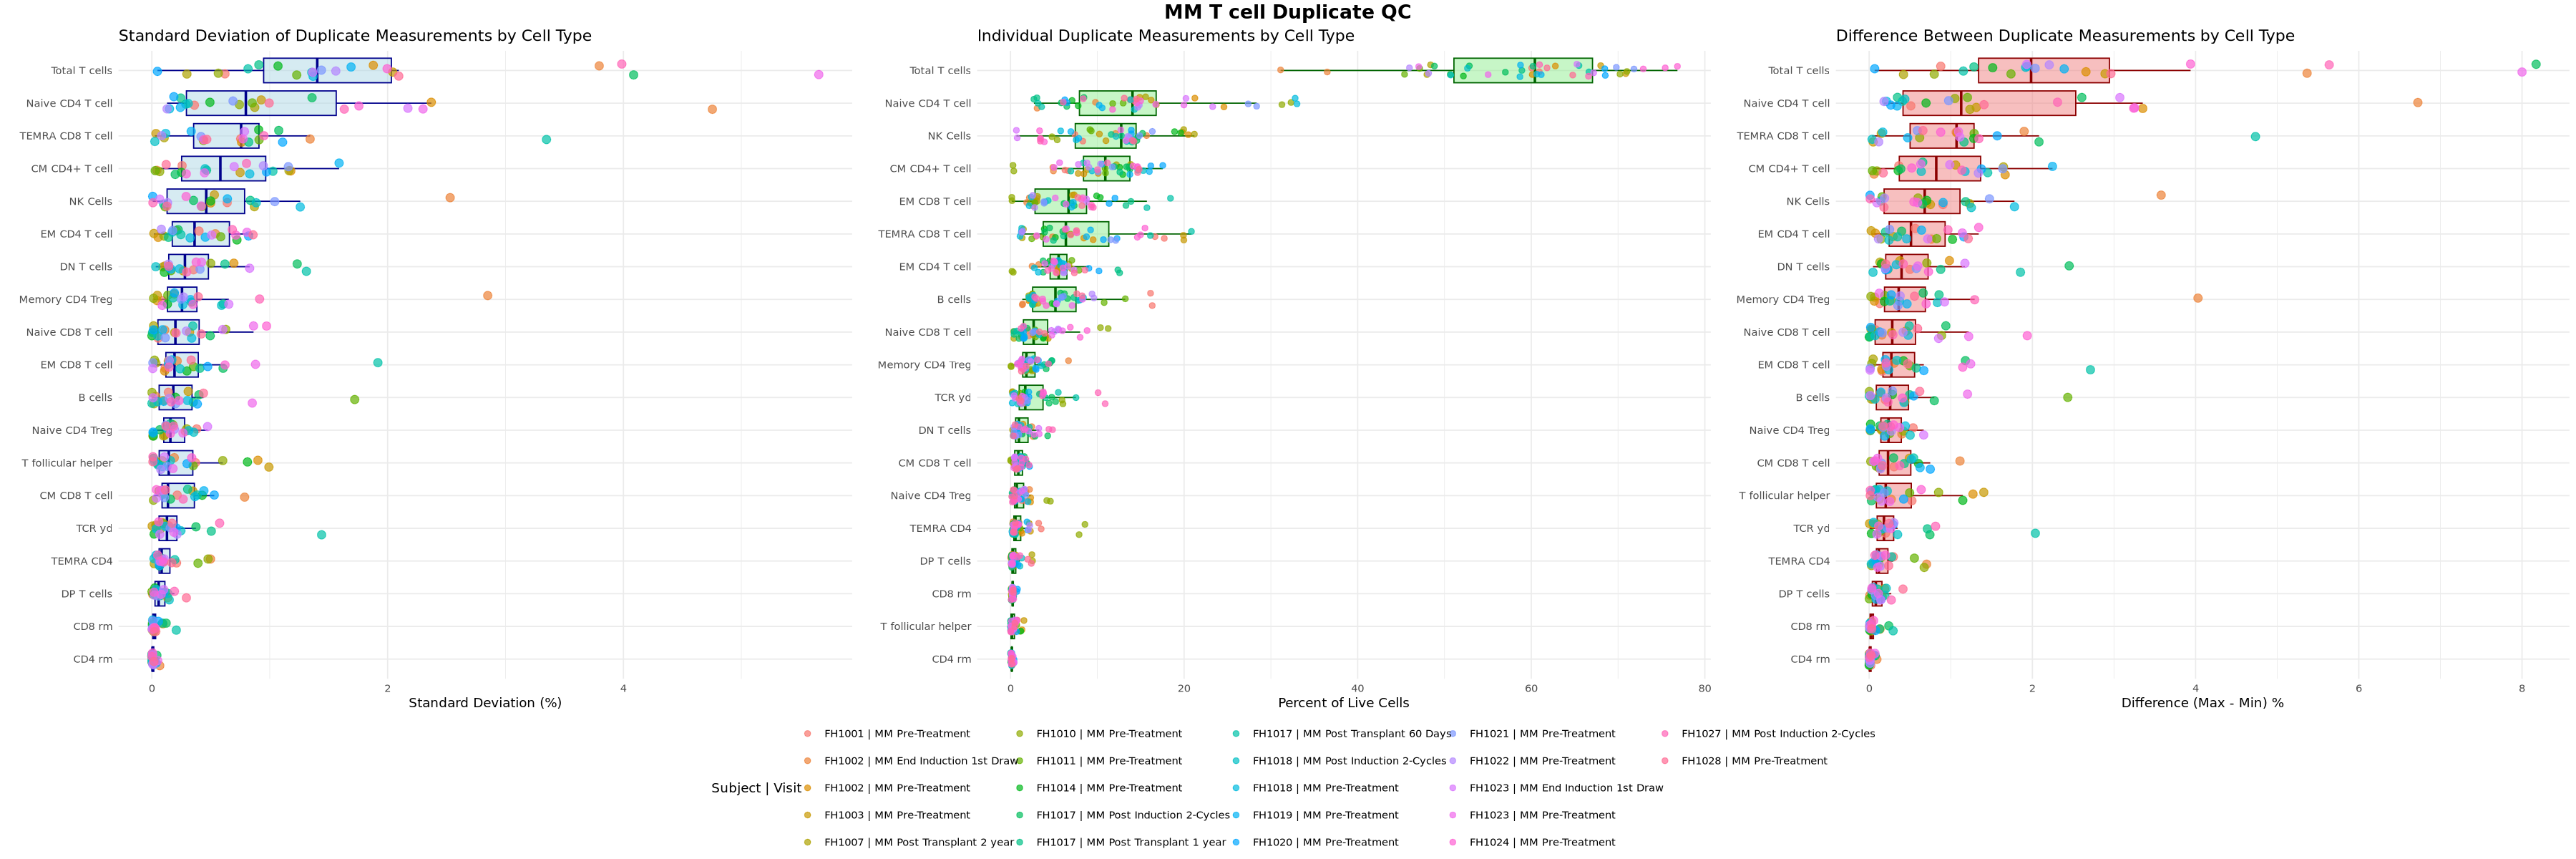

In [7]:
options(repr.plot.width = 30, repr.plot.height = 10)

# Duplicate measurement analysis and visualization function
plot_duplicate_analysis <- function(df,
                                    timepoints = NULL,
                                    save_plot = TRUE,
                                    visit_col = "flu_visit",
                                    subject_col = "Subject",
                                    data_type = NULL,
                                    alpha = 0.7,
                                    ncol = 3,
                                    nrow = 1) {

    df <- df[df[[visit_col]] %in% names(timepoints), ]
    
    # Count duplicate measurements per subject-visit-population combination
    duplicate_counts <- aggregate(df[["percent"]], 
                                by = df[c(subject_col, visit_col, "population")], 
                                FUN = length)
    
    names(duplicate_counts)[4] <- "N"
    
    # Filter to only combinations with duplicates (N > 1)
    duplicates_only <- duplicate_counts[duplicate_counts$N > 1, ]

    # Early exit if no duplicates found
    if (nrow(duplicates_only) == 0) {
        return(NULL)
    }
    
    # Extract unique subject-visit combinations that have duplicates
    duplicate_combos <- unique(duplicates_only[, c(subject_col, visit_col)])
    
    # Filter original data to only duplicate measurements
    duplicate_data <- merge(df, duplicate_combos, by = c(subject_col, visit_col))
    duplicate_data$combo_id <- paste(duplicate_data[[subject_col]], duplicate_data[[visit_col]], sep = " | ")
    
    # Calculate summary statistics for each cell population with duplicates
    duplicate_stats <- aggregate(duplicate_data[["percent"]],
                               by = list(cell = duplicate_data[["population"]], 
                                       combo = duplicate_data$combo_id),
                               FUN = function(x) c(mean = mean(x), 
                                                 sd = sd(x),
                                                 min = min(x),
                                                 max = max(x),
                                                 diff = max(x) - min(x)))
    
    # Convert aggregated results to a clean data frame
    duplicate_stats <- data.frame(
        cell = duplicate_stats$cell,
        combo = duplicate_stats$combo,
        mean_percent = duplicate_stats$x[,"mean"],
        sd_percent = duplicate_stats$x[,"sd"],
        min_percent = duplicate_stats$x[,"min"],
        max_percent = duplicate_stats$x[,"max"],
        diff_percent = duplicate_stats$x[,"diff"]
    )
    
    # Create detailed combo ID that includes cell type for plots 1 and 3
    duplicate_stats$combo_with_cell <- paste(duplicate_stats$combo, duplicate_stats$cell, sep = " | ")
    
    # Plot 1: Box plot of standard deviation with individual points colored by subject-visit combo
    p1 <- ggplot(duplicate_stats, aes(x = reorder(cell, sd_percent, FUN = median), y = sd_percent)) +
        geom_boxplot(alpha = 0.5, fill = "lightblue", color = "darkblue", outlier.shape = NA) +
        geom_jitter(aes(color = combo), width = 0.2, size = 3, alpha = alpha) +
        coord_flip() +
        labs(title = "Standard Deviation of Duplicate Measurements by Cell Type",
             x = "",
             y = "Standard Deviation (%)",
             color = "Subject | Visit") +
        theme_minimal() +
        guides(color = guide_legend(override.aes = list(size = 2)))
    
    # Plot 2: Box plot of individual duplicate measurements with points colored by subject-visit combo
    p2 <- ggplot(duplicate_data, aes(x = reorder(!!sym("population"), !!sym("percent"), FUN = median), y = !!sym("percent"))) +
        geom_boxplot(alpha = 0.5, fill = "lightgreen", color = "darkgreen", outlier.shape = NA) +
        geom_jitter(aes(color = combo_id), width = 0.2, size = 2, alpha = alpha) +
        coord_flip() +
        labs(title = "Individual Duplicate Measurements by Cell Type",
             x = "",
             y = "Percent of Live Cells",
             color = "Subject | Visit") +
        theme_minimal() +
        guides(color = guide_legend(override.aes = list(size = 2)))
    
    # Plot 3: Box plot of differences with individual points colored by subject-visit combo
    p3 <- ggplot(duplicate_stats, aes(x = reorder(cell, diff_percent, FUN = median), y = diff_percent)) +
        geom_boxplot(alpha = 0.5, fill = "lightcoral", color = "darkred", outlier.shape = NA) +
        geom_jitter(aes(color = combo), width = 0.2, size = 3, alpha = alpha) +
        coord_flip() +
        labs(title = "Difference Between Duplicate Measurements by Cell Type",
             x = "",
             y = "Difference (Max - Min) %",
             color = "Subject | Visit") +
        theme_minimal() +
        guides(color = guide_legend(override.aes = list(size = 2)))
    
    # Combine all plots into a single visualization
    plots <- list(p1, p2, p3)
    combined_plot <- ggpubr::ggarrange(plotlist = plots, common.legend = TRUE, legend = "bottom", ncol = ncol, nrow = nrow)

    title = paste0(data_type, " ", unique(df$formal_celltype), " Duplicate QC")
    combined_plot <- ggpubr::annotate_figure(combined_plot, top = ggpubr::text_grob(title, size = 16, face = "bold"))

    # Create output directory for plots if it doesn't exist
    dir.create("plots", showWarnings = FALSE)
    dir.create("plots/qc", showWarnings = FALSE)
    dir.create("plots/qc/duplicates", showWarnings = FALSE)
                                 
    if (save_plot) {
        filename <- tolower(paste0(data_type, "_", unique(df$informal_celltype), "_duplicate_qc.png"))
        ggsave(file.path("plots/qc/duplicates", filename),
               plot = combined_plot, 
               width = 20, 
               height = 10, 
               dpi = 300,
               bg = "white")
    }
    
    return(combined_plot)
}

# Generate duplicate analysis plots for flu datasets
flu_duplicate_plots <- lapply(raw_dfs, function(x) {
    plot_duplicate_analysis(x, visit_col = "Flu.Visit", timepoints = flu_timepoints, data_type = "Flu")
})

# Generate duplicate analysis plots for MM datasets
mm_duplicate_plots <- lapply(raw_dfs, function(x) {
    plot_duplicate_analysis(x, visit_col = "MM.Visit", timepoints = mm_timepoints, data_type = "MM")
})

# Display the flu duplicate plots
print(flu_duplicate_plots)

# Display the MM duplicate plots
print(mm_duplicate_plots)

## 3. Data Processing & Standardization

### Processing Functions

#### Duplicate Handling Function

In [8]:
handle_duplicates <- function(df, 
                            subject_col = "subject.subjectGuid",
                            visit_col = "visit", 
                            label_col = "aifi_label_l2",
                            value_col = "counts",
                            use_duplicates = TRUE) {
    
    # Define grouping columns
    grouping_cols <- c(subject_col, visit_col, label_col)
    
    if (use_duplicates) {
        # Aggregate the value column by grouping columns
        agg <- aggregate(df[[value_col]],
                        by = df[grouping_cols],
                        FUN = mean)
        names(agg)[length(names(agg))] <- value_col
        
        # Create group ID for identifying unique groups
        df$group_id <- paste(df[[subject_col]], df[[visit_col]], df[[label_col]], sep="_")
        first <- df[!duplicated(df$group_id), ]
        first$group_id <- NULL
        
        # Merge non-value columns with aggregated values
        df <- merge(first[, !names(first) %in% value_col], 
                   agg, 
                   by = grouping_cols)
    } else {
        # Remove all rows that have duplicates
        df <- df[!duplicated(df[grouping_cols]) & 
                !duplicated(df[grouping_cols], fromLast = TRUE), ]
    }
    
    return(df)
}

#### Absolute Lymphocyte Count (ALC) Normalization Function

In [9]:
add_cell_counts <- function(df, alc_df, label_col = "aifi_label_l2") {
    b_cells <- c("B cells", "B Cells")
    t_cells <- c("T cells", "T Cells", "Total T cells")
    nk_cells <- c("NK cells", "NK Cells")
    
    kit_ls <- unique(df$Sample.Kit.Barcode)
    
    for (x in seq_along(kit_ls)) {
        kit_rows <- df$Sample.Kit.Barcode == kit_ls[[x]]
        subset <- df[kit_rows, ]
        
        t_cell <- subset[subset[[label_col]] %in% t_cells, "counts"]
        b_cell <- subset[subset[[label_col]] %in% b_cells, "counts"]
        nk_cell <- subset[subset[[label_col]] %in% nk_cells, "counts"]
        alc <- alc_df[alc_df$sampleKitGuid == kit_ls[[x]], "ALC"]
        
        df[kit_rows, "t_cells"] <- t_cell[1]
        df[kit_rows, "b_cells"] <- b_cell[1]
        df[kit_rows, "nk_cells"] <- nk_cell[1]
        df[kit_rows, "alc"] <- alc[1]
    }

    # df <- df[!is.na(df$alc), ]
    
    lymphocyte_total <- df$t_cells + df$b_cells + df$nk_cells
    df$estimated_absolute_count <- df$counts * df$alc / lymphocyte_total
    
    return(df)
}

#### Frequency Generation Function

In [10]:
generate_frequencies <- function(df,
                                 celltypes,
                                 visit_col,
                                 label_col = "aifi_label_l2",
                                 subject_col = "subject.subjectGuid") {
    
    df$Sample_ID <- paste(df[[subject_col]], df[[visit_col]], sep = "_")
    
    df <- df[df[[label_col]] %in% celltypes, ]
    
    df$total_counts <- ave(df$counts, df$Sample_ID, FUN = function(x) sum(x, na.rm = TRUE))
    df$alc_totals <- ave(df$estimated_absolute_count, df$Sample_ID, FUN = function(x) sum(x, na.rm = TRUE))
    
    df$raw_frequency <- df$counts / df$total_counts
    df$alc_frequency <- df$estimated_absolute_count / df$alc_totals
    
    return(df)
}

#### CLR Transformation Function

In [11]:
clr_transform <- function(df) {
    result_list <- by(df, df$Sample_ID, function(sample_data) {
        
        pseudocount <- 1
        sample_data$pseudo_counts <- sample_data$counts + pseudocount
        sample_data$pseudo_alc <- sample_data$estimated_absolute_count + pseudocount
        
        pseudo_total_counts <- sum(sample_data$pseudo_counts, na.rm = TRUE)
        pseudo_total_alc <- sum(sample_data$pseudo_alc, na.rm = TRUE)
        
        counts_frequency <- sample_data$pseudo_counts / pseudo_total_counts
        alc_frequency <- sample_data$pseudo_alc / pseudo_total_alc
        
        counts_gm <- exp(mean(log(counts_frequency)))
        alc_gm <- exp(mean(log(alc_frequency)))
        
        sample_data$counts_clr <- log(counts_frequency / counts_gm)
        sample_data$alc_clr <- log(alc_frequency / alc_gm)
        
        return(sample_data)
    })
    
    result_df <- do.call(rbind, result_list)
    
    return(result_df)
}

### General Data Preprocessing

In [12]:
responder_map <- c(
    "Responder" = "flu_responder",
    "Non responder" = "flu_non_responder",
    "None" = "None"
)

# Mapping to fix incorrect celltype names in myeloid data
celltype_naming_map <- c(
    "Plamsacytoid DC" = "Plasmacytoid DC",
    "CD56 bright NK cell" = "CD56bright NK cell",
    "CD56 lo" = "CD56dim NK cell",
    "CD16+ CD56 lo" = "CD16+CD56dim NK cell"
)

dfs <- lapply(raw_dfs, function(df) {
    df$percentOf <- "Total Viable Cells"

    names(df)[names(df) == "eventCount"] <- "counts"
    names(df)[names(df) == "Subject"] <- "subject.subjectGuid"
    names(df)[names(df) == "Flu.Visit"] <- "sample.visitName"
    names(df)[names(df) == "MM.Visit"] <- "sample.visitDetails"
    names(df)[names(df) == "Flu.response"] <- "manual.flu_response"
    names(df)[names(df) == "population"] <- "aifi_label_l2"

    df$manual.flu_response[df$manual.flu_response == ""] <- "None"

    df$manual.flu_response <- responder_map[df$manual.flu_response]

    # Correct incorrect celltype names
    df$aifi_label_l2[df$aifi_label_l2 %in% names(celltype_naming_map)] <- celltype_naming_map[df$aifi_label_l2[df$aifi_label_l2 %in% names(celltype_naming_map)]]

    #df <- df[df$subject.subjectGuid != "FH1024", ]

    return(df)
})

### Flu-Specific Data Processing

In [13]:
flu_dfs <- lapply(seq_along(dfs), function(i) {
    
    flu_df <- dfs[[i]]

    flu_df <- flu_df[flu_df[["sample.visitName"]] %in% names(flu_timepoints), ]

    flu_df$label.visitName <- flu_timepoints[flu_df$sample.visitName]

    flu_df <- handle_duplicates(
        flu_df, 
        subject_col = "subject.subjectGuid",
        visit_col = "sample.visitName", 
        label_col = "aifi_label_l2",
        value_col = "counts",
        use_duplicates = TRUE
    )

    flu_df <- add_cell_counts(flu_df, alc_df)

    celltype_name <- unique(flu_df$informal_celltype)
    if (celltype_name == "bcell") {
        selected_celltypes <- bcell_celltypes
    } else if (celltype_name == "tcell") {
        selected_celltypes <- tcell_celltypes
    } else if (celltype_name == "myeloid") {
        selected_celltypes <- myeloid_celltypes
    } else if (celltype_name == "survey") {
        selected_celltypes <- survey_celltypes
    } else {
        selected_celltypes <- unique(flu_df$aifi_label_l2)
    }

    flu_df <- generate_frequencies(flu_df, selected_celltypes, visit_col = "sample.visitName")
    
    flu_df <- clr_transform(flu_df)

    return(flu_df)
})

### MM Specific Data Processing

In [14]:
mm_dfs <- lapply(seq_along(dfs), function(i) {
    mm_df <- dfs[[i]]

    mm_df$sample.visitDetails[mm_df$sample.visitDetails == "N/A - Flu-Series Timepoint Only"] <- "Healthy"
    
    mm_df <- mm_df[mm_df[["sample.visitDetails"]] %in% names(mm_timepoints), ]
    mm_df <- mm_df[!(mm_df$Cohort == "FH1" & mm_df$sample.visitDetails == "Healthy"), ]

    mm_df$label.visitDetails <- mm_timepoints[mm_df$sample.visitDetails]

    mm_df <- add_cell_counts(mm_df, alc_df)

    subjects_with_60d <- unique(mm_df$subject.subjectGuid[mm_df$sample.visitDetails == "MM Post Transplant 60 Days"])
    subjects_with_90d_only <- mm_df$subject.subjectGuid[mm_df$sample.visitDetails == "MM Post Transplant 90 Days" & 
                                                        !mm_df$subject.subjectGuid %in% subjects_with_60d]
    
    mm_df$sample.visitDetails[mm_df$sample.visitDetails == "MM Post Transplant 90 Days" & 
                              mm_df$subject.subjectGuid %in% subjects_with_90d_only] <- "MM Post Transplant 60 Days"
    mm_df$label.visitDetails[mm_df$label.visitDetails == "ASCT90d" & 
                             mm_df$subject.subjectGuid %in% subjects_with_90d_only] <- "ASCT60d"

    mm_df <- mm_df[!(mm_df$subject.subjectGuid == "FH1003" & mm_df$sample.visitDetails == "MM Post Transplant 90 Days"), ]
    mm_df <- mm_df[!(mm_df$subject.subjectGuid == "FH1024" & mm_df$sample.visitDetails == "MM Post Transplant 90 Days"), ]

    mm_df <- handle_duplicates(
        mm_df, 
        subject_col = "subject.subjectGuid",
        visit_col = "sample.visitDetails", 
        label_col = "aifi_label_l2",
        value_col = "counts",
        use_duplicates = TRUE
    )

    celltype_name <- unique(mm_df$informal_celltype)
    if (celltype_name == "bcell") {
        selected_celltypes <- bcell_celltypes
    } else if (celltype_name == "tcell") {
        selected_celltypes <- tcell_celltypes
    } else if (celltype_name == "myeloid") {
        selected_celltypes <- myeloid_celltypes
    } else if (celltype_name == "survey") {
        selected_celltypes <- survey_celltypes
    } else {
        selected_celltypes <- unique(mm_df$aifi_label_l2)
    }

    mm_df <- generate_frequencies(mm_df, selected_celltypes, visit_col = "sample.visitDetails")
    mm_df <- clr_transform(mm_df)

    return(mm_df)
})

## 4. Post-Processing QC

### Population Names

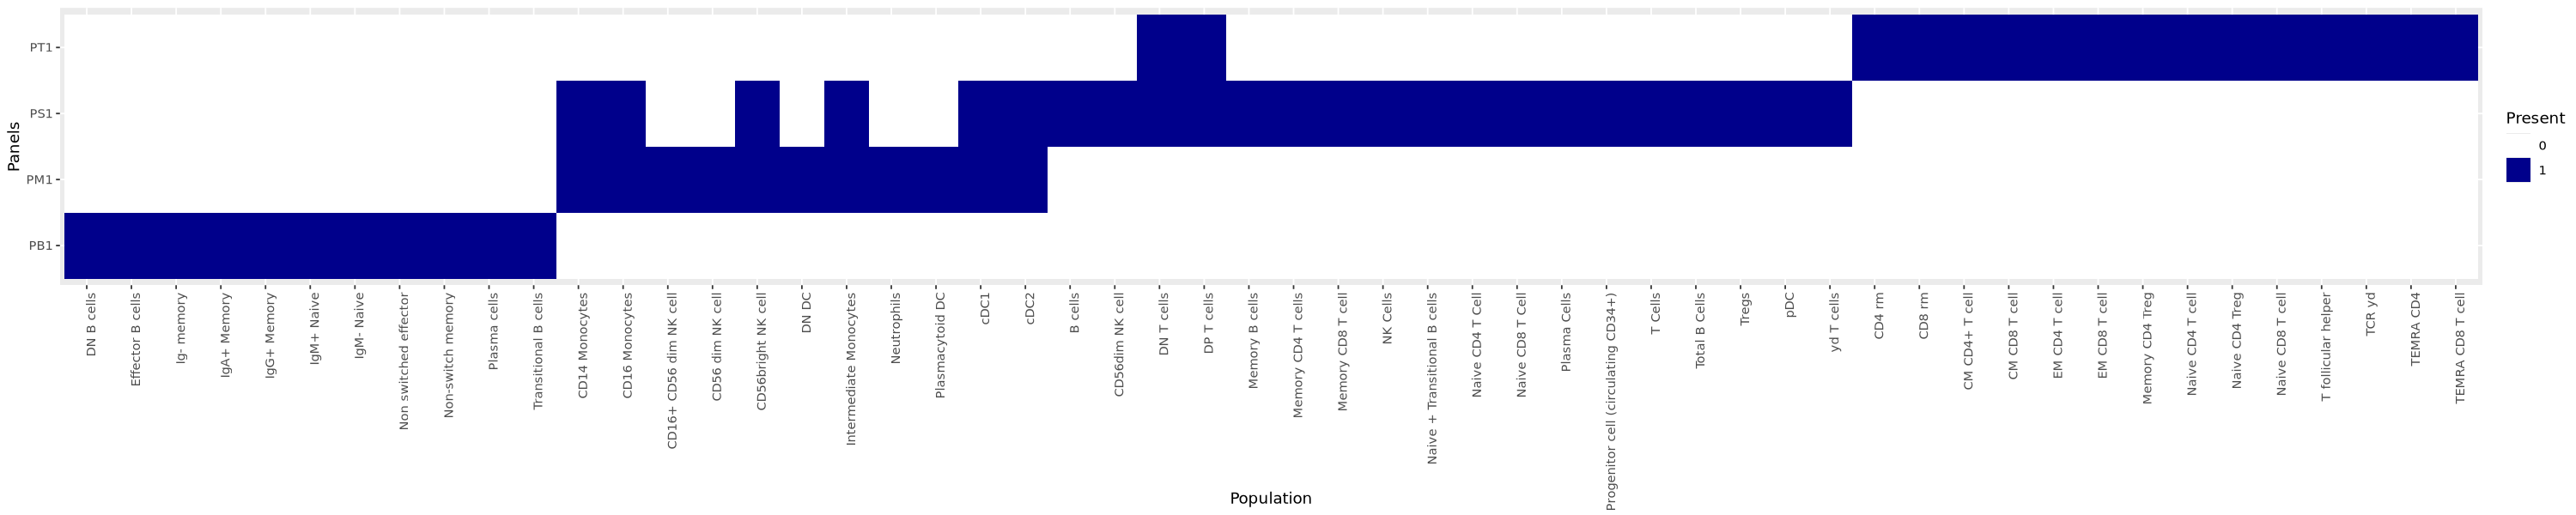

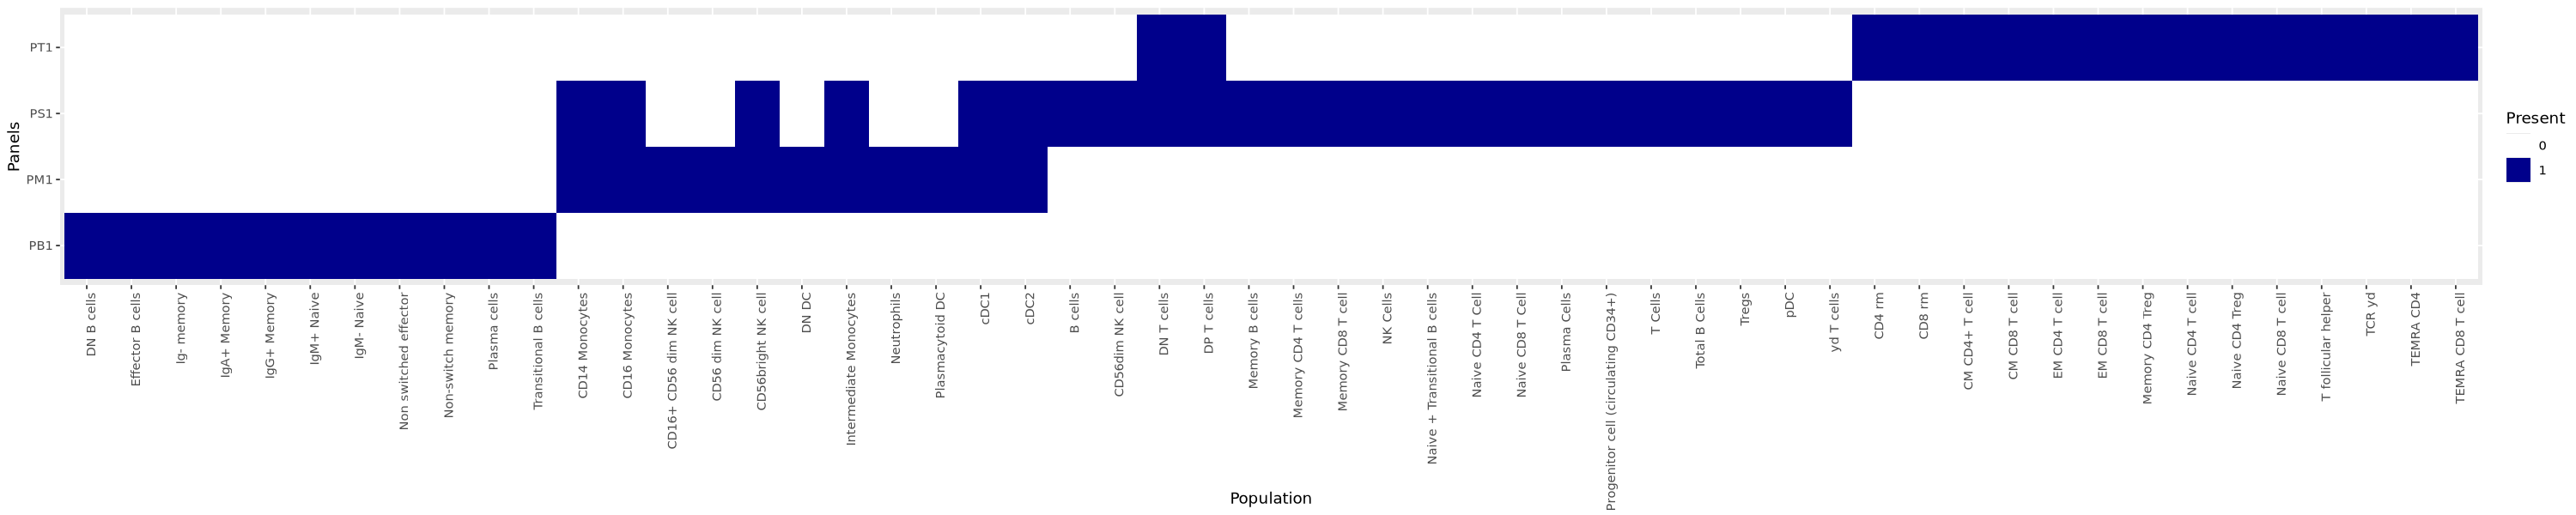

In [15]:
options(repr.plot.width = 25, repr.plot.height = 5)

plot_population_names <- function(dfs,
                                  label_col = "aifi_label_l2") {

    pop_ls <- lapply(dfs, function(df) {unique(df[[label_col]])})
    all_pop <- unique(unlist(pop_ls))
    
    panel_ids <- sapply(dfs, function(df) unique(df$panel))
    
    pop_mtx <- matrix(0, nrow = length(dfs), ncol = length(all_pop))
    rownames(pop_mtx) <- panel_ids
    colnames(pop_mtx) <- all_pop
    
    for(i in 1:length(dfs)) {
      pop_mtx[i, pop_ls[[i]]] <- 1
    }
    
    # Convert to long format for ggplot
    heatmap_data <- expand.grid(Panels = rownames(pop_mtx), Population = colnames(pop_mtx))
    heatmap_data$Present <- as.vector(pop_mtx)
    
    # Create ggplot heatmap
    pop_plot <- ggplot(heatmap_data, aes(x = Population, y = Panels, fill = factor(Present))) +
      geom_tile() +
      scale_fill_manual(values = c("0" = "white", "1" = "darkblue")) +
      theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
      labs(fill = "Present")
    
    print(pop_plot)
    
}

pop_plot <- plot_population_names(flu_dfs)

ggsave("plots/qc/post_processing_flu_population_names.png", 
       plot = pop_plot, 
       width = 25, 
       height = 5, 
       dpi = 300,
       bg = "white")
                        
pop_plot <- plot_population_names(mm_dfs)

ggsave("plots/qc/post_processing_mm_population_names.png", 
       plot = pop_plot, 
       width = 25, 
       height = 5, 
       dpi = 300,
       bg = "white")

### Sample Availability Visualization

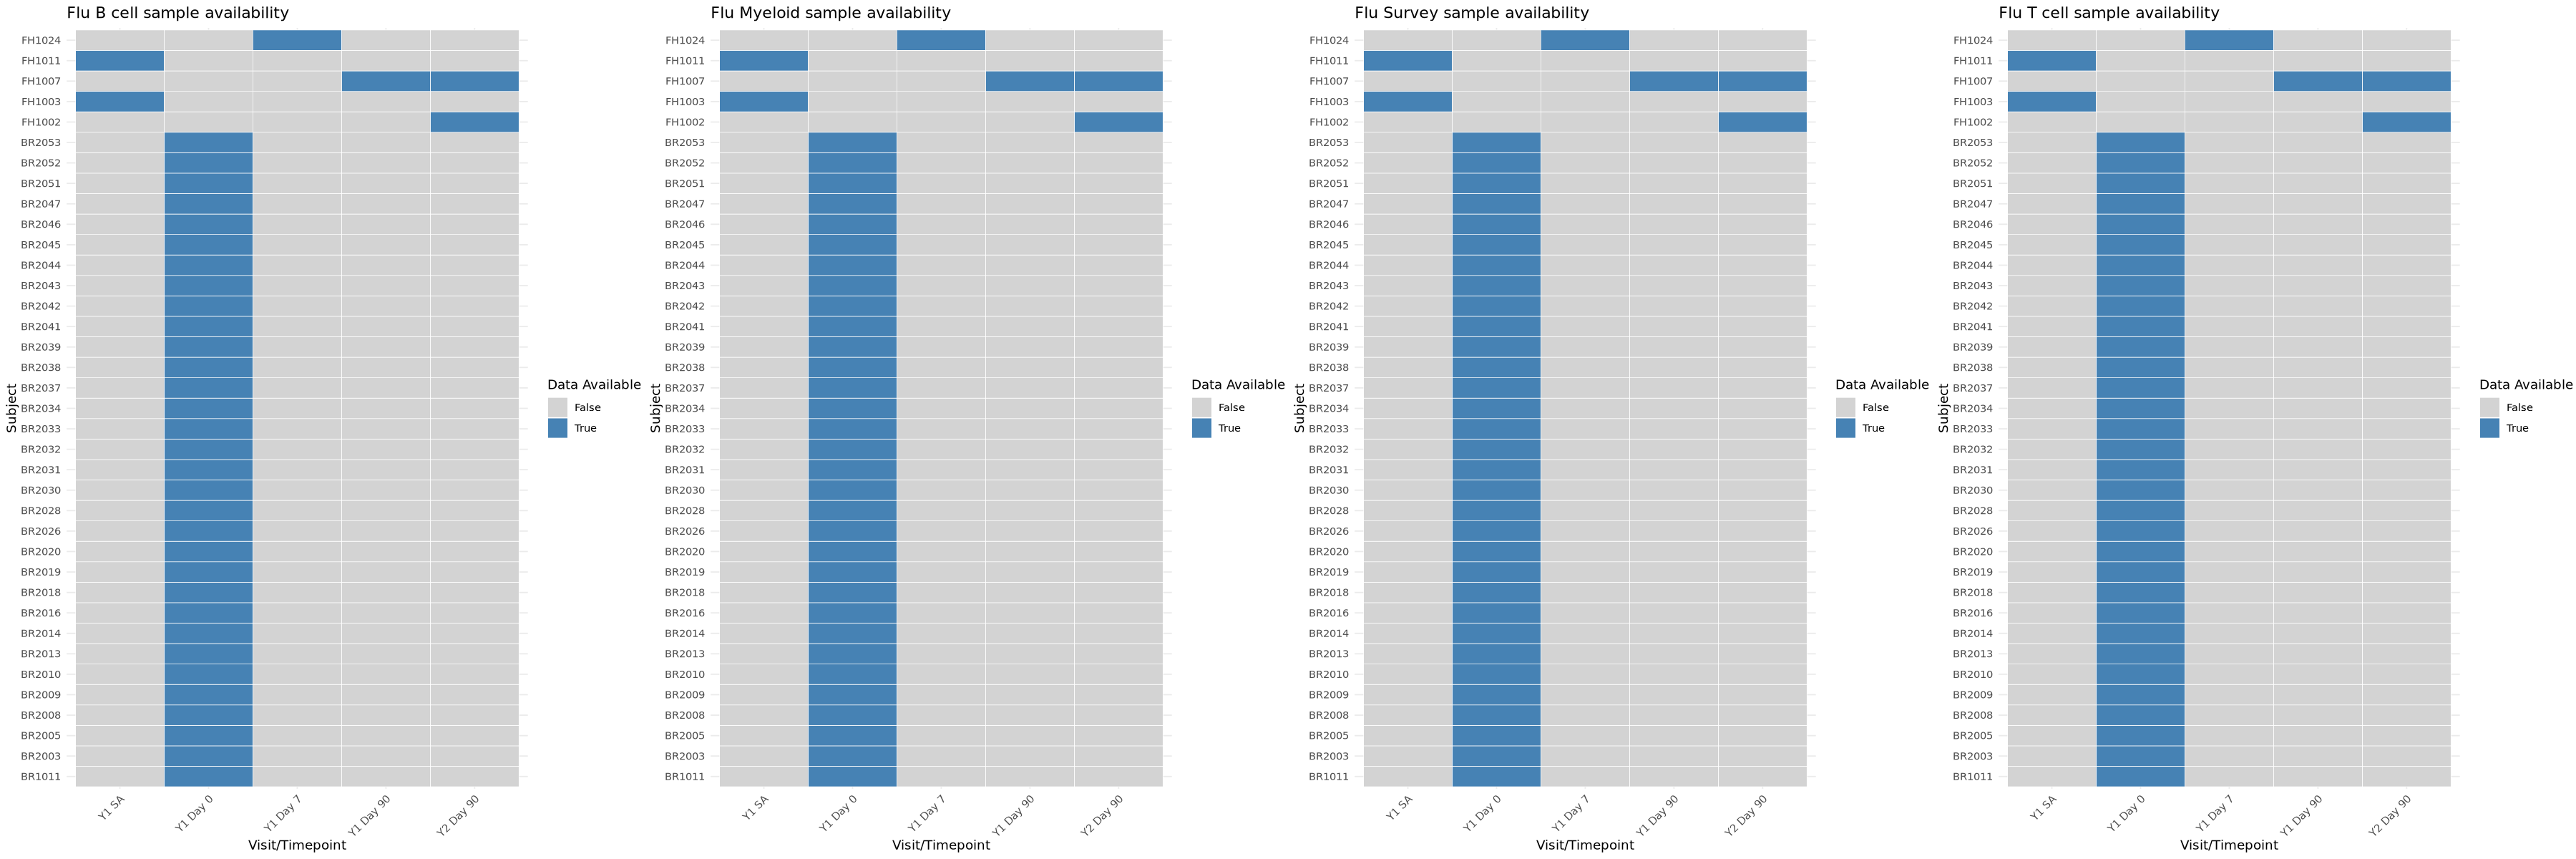

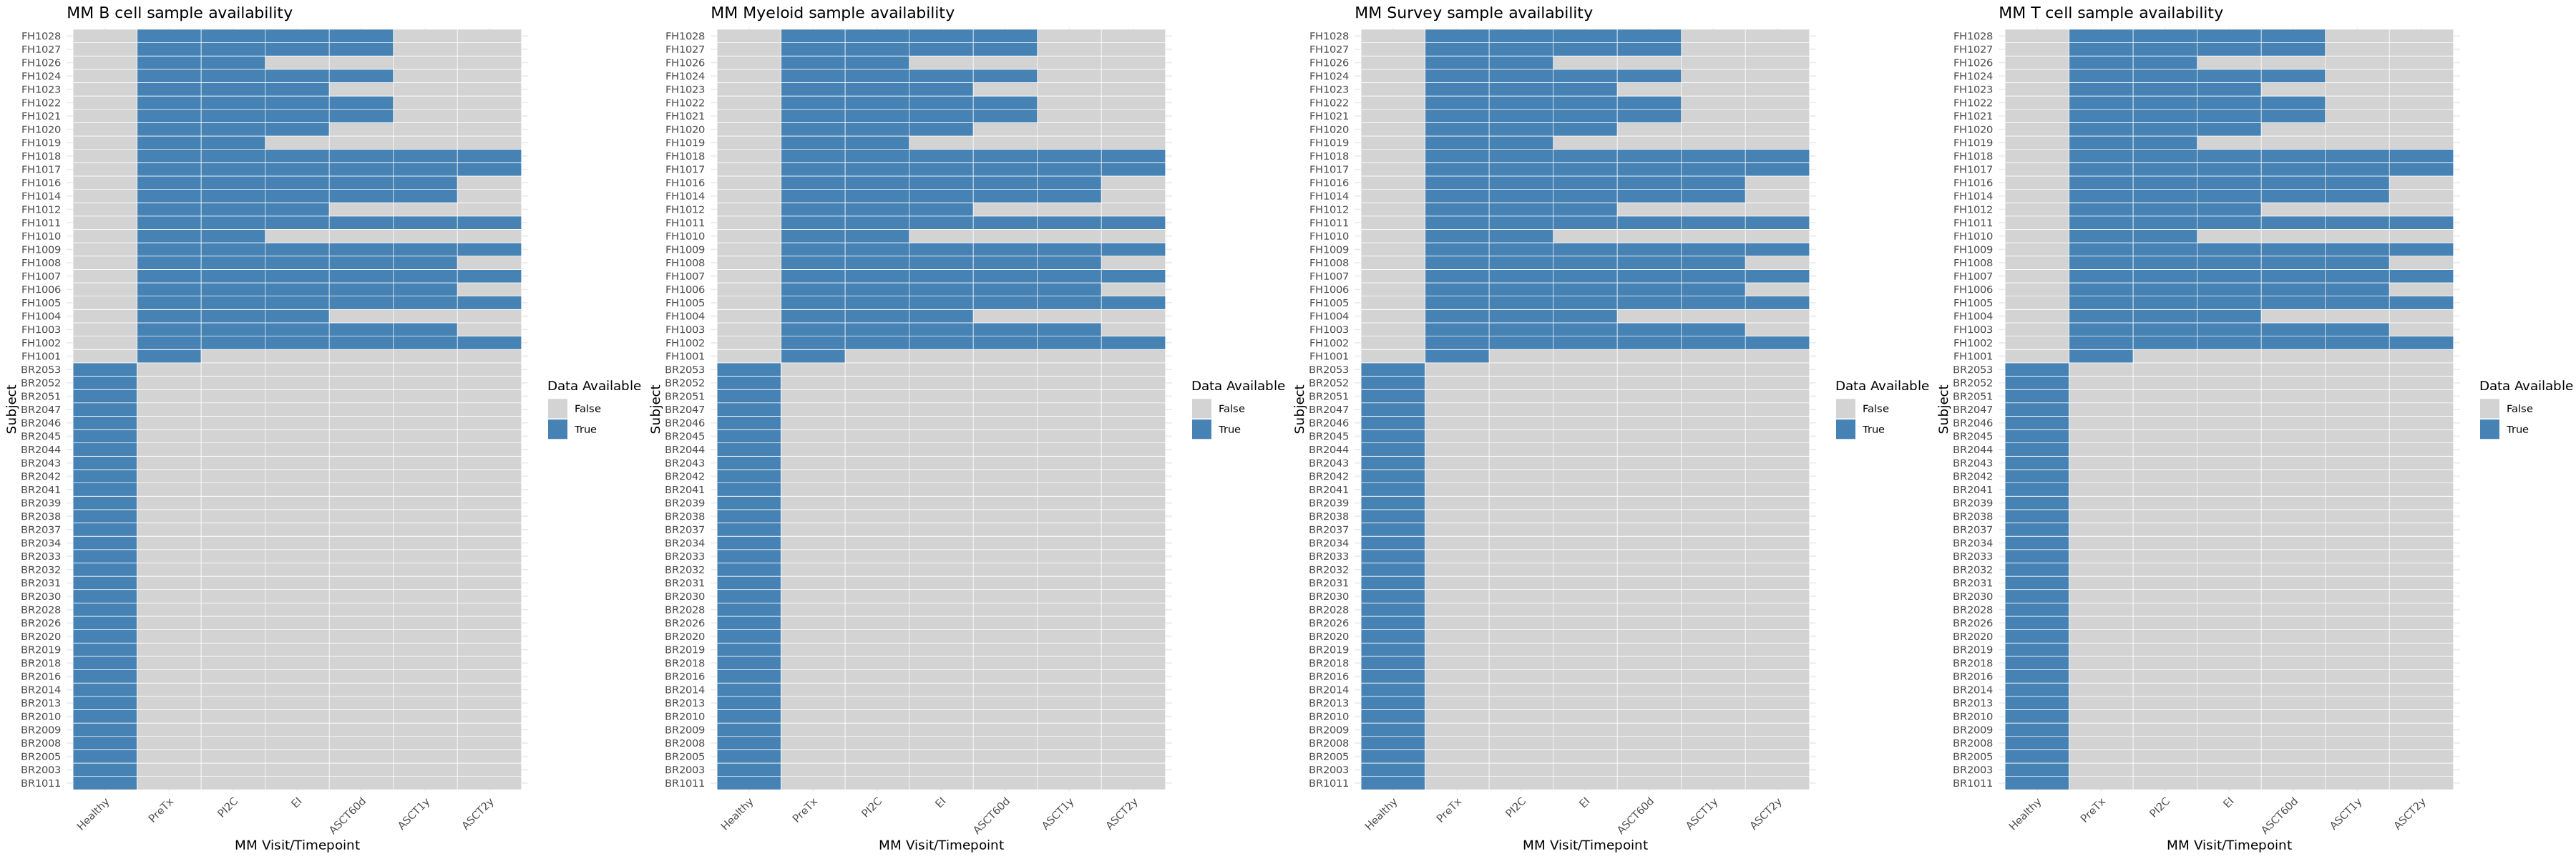

In [16]:
options(repr.plot.width = 30, repr.plot.height = 10)

# Sample availability visualization function
plot_sample_availability <- function(df,
                                     visit_col = "flu_visit",
                                     subject_col = "subject.subjectGuid",  # Add this parameter
                                     datatype = c("Flu", "MM"),
                                     timepoint_labels = "flu_timepoints",
                                     x_label = "Visit/Timepoint",
                                     y_label = "Subject",
                                     present_color = "steelblue",
                                     absent_color = "lightgray") {
  
    # Calculate number of timepoints per subject for summary statistics
    visit_formula <- as.formula(paste(visit_col, "~", subject_col))  # Use subject_col parameter
    timepoints_per_subject <- aggregate(visit_formula, df, function(x) length(unique(x)))
    names(timepoints_per_subject)[2] <- "num_timepoints"
    
    # Extract unique subject-visit combinations and mark as present
    timepoint_data <- unique(df[, c(subject_col, visit_col)])  # Use subject_col parameter
    timepoint_data$present <- 1
    
    # Get all possible subjects and visits for complete grid
    all_subjects <- unique(timepoint_data[[subject_col]])  # Use subject_col parameter
    all_visits <- unique(timepoint_data[[visit_col]])
    
    # Create complete grid of all subject-visit combinations
    complete_grid <- expand.grid(subject = all_subjects, visit = all_visits)
    names(complete_grid) <- c(subject_col, visit_col)  # Use proper column names
    
    # Merge with actual data to identify missing combinations
    plot_data <- merge(complete_grid, timepoint_data, all.x = TRUE)
    plot_data$present[is.na(plot_data$present)] <- 0  # Mark missing data as absent
    
    # Apply custom timepoint labels if provided
    if (!is.null(timepoint_labels)) {
        plot_data[[visit_col]] <- factor(plot_data[[visit_col]], 
                                         levels = names(timepoint_labels), 
                                         labels = timepoint_labels)
    } else {
        plot_data[[visit_col]] <- factor(plot_data[[visit_col]], 
                                         levels = sort(all_visits))
    }
    
    # Order subjects for consistent display
    plot_data[[subject_col]] <- factor(plot_data[[subject_col]], 
                                       levels = sort(all_subjects))  # Use subject_col parameter
    
    # Create heatmap visualization
    p <- ggplot(plot_data, aes(x = !!sym(visit_col), y = !!sym(subject_col), fill = factor(present))) +
        geom_tile(color = "white") +
        scale_fill_manual(values = c("0" = absent_color, "1" = present_color), 
                          labels = c("0" = "False", "1" = "True"),
                          name = "Data Available") +
        theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
        labs(title = paste0(datatype, " ", unique(df$formal_celltype), " sample availability"), 
             x = x_label, y = y_label)
    
    return(p)
}

# Create output directory for plots if it doesn't exist
dir.create("plots/qc/sample_availability", showWarnings = FALSE)

# Generate sample availability plots for flu datasets
flu_sample_plots <- lapply(flu_dfs, function(x) {
    plot_sample_availability(
        x,
        visit_col = "sample.visitName",
        subject_col = "subject.subjectGuid",  # Explicitly specify
        datatype = "Flu",
        timepoint_labels = flu_timepoints
    )
})

# Generate sample availability plots for MM datasets  
mm_sample_plots <- lapply(mm_dfs, function(x) {
    plot_sample_availability(
        x,
        visit_col = "sample.visitDetails",
        subject_col = "subject.subjectGuid",  # Explicitly specify
        datatype = "MM",
        timepoint_labels = mm_timepoints,
        x_label = "MM Visit/Timepoint"
    )
})

# Combine flu plots into a single figure
flu_combined <- ggpubr::ggarrange(plotlist = flu_sample_plots, nrow = 1)
print(flu_combined)

# Save flu sample availability plot as PNG
ggsave("plots/qc/sample_availability/flu_sample_availability.png", 
       plot = flu_combined, 
       width = 30, 
       height = 10, 
       dpi = 300,
       bg = "white")

# Combine MM plots into a single figure
mm_combined <- ggpubr::ggarrange(plotlist = mm_sample_plots, nrow = 1)
print(mm_combined)

# Save MM sample availability plot as PNG
ggsave("plots/qc/sample_availability/mm_sample_availability.png", 
       plot = mm_combined, 
       width = 30, 
       height = 10, 
       dpi = 300,
       bg = "white")

## 5. Data Export

In [17]:
# Enhanced data export function for separate flu and MM datasets
export_processed_data <- function(flu_dfs, mm_dfs, output_path = "../data/flow/output/") {
        
    # Export MM datasets
    for (i in seq_along(mm_dfs)) {
        celltype <- unique(mm_dfs[[i]]$informal_celltype)
        
        # Data is already filtered to relevant timepoints during processing
        mm_filename <- paste0("processed_mm_", celltype, "_data.csv")
        write.csv(mm_dfs[[i]], file.path(output_path, mm_filename), row.names = FALSE)
    }
}

# Export all processed data using separate flu and MM datasets
export_processed_data(flu_dfs, mm_dfs)

## Combine all panels into a single file

In [18]:
# Read all panel-specific compositional data files
mm_data_files <- list("../data/flow/output/processed_mm_bcell_data.csv",
                      "../data/flow/output/processed_mm_myeloid_data.csv",
                      "../data/flow/output/processed_mm_tcell_data.csv")

mmFiles = lapply(mm_data_files, function(x) fread(x))
mmFiles <- rbindlist(mmFiles, use.names = T)

In [19]:
### in the survey panel we only keep progenitor cells
survey = fread("../data/flow/output/processed_mm_survey_data.csv" )
survey = survey[aifi_label_l2 == 'Progenitor cell (circulating CD34+)']

### Combine all files 
mmFiles = rbind(mmFiles, survey)

### Refactor all 'BRI' subjects as healthy
mmFiles[mmFiles$Cohort=='BR1',]$Cohort <- 'Healthy'
mmFiles[mmFiles$Cohort=='BR2',]$Cohort <- 'Healthy'

### Fix naming convention for DC subsets
mmFiles$aifi_label_l2[mmFiles$aifi_label_l2=='Other DC > cDC1'] <-'cDC1'
mmFiles$aifi_label_l2[mmFiles$aifi_label_l2=='Other DC > cDC2'] <-'cDC2'

write.csv(mmFiles, '../data/flow/output/aggregated_flowdata.csv')